In [2]:
from Database.DB_reader import Database
import pandas as pd

In [3]:
db = Database()

In [89]:
instrument = 'F7BM'
actor = 'Commer'
query = f"""
    SELECT *
    FROM "cot"."cot_entries"
    WHERE instrument = '{instrument}';
    """

In [90]:
raw = pd.read_sql(query, db.connection_string)
raw['date'] = pd.to_datetime(raw['date'])
long = raw.loc[raw['direction']=='long'].set_index('date').sort_index().copy()
short = raw.loc[raw['direction'] == 'short'].set_index('date').sort_index().copy()


In [91]:
# 1. compute vol_pct on the short and long side too
# bring the date back as a column
long = long.reset_index()

# compute volume-% within each (date, instrument, direction) bucket
long['vol_pct'] = (
    long
      .groupby(['date','instrument','direction'])['volume']
      .transform(lambda x: x / x.sum() * 100)
)

# if you like, restore date as index
long = long.set_index('date')

short = short.reset_index()
short['vol_pct'] = (
    short
      .groupby(['date','instrument','direction'])['volume']
      .transform(lambda x: x / x.sum() * 100)
)
short = short.set_index('date')

# 2. merge long & short percentages
net = pd.merge(
    long[['instrument','actor','risk_reducing','vol_pct']],
    short[['instrument','actor','risk_reducing','vol_pct']],
    left_on=['date','instrument','actor','risk_reducing'],
    right_on=['date','instrument','actor','risk_reducing'],
    how='outer',
    suffixes=('_long','_short')
)

# fill missing with 0
net[['vol_pct_long','vol_pct_short']] = net[['vol_pct_long','vol_pct_short']].fillna(0)

# 3. compute netted vol_pct
net['vol_pct_net'] = net['vol_pct_long'] - net['vol_pct_short']

# tidy up
net = net.drop(columns=['vol_pct_long','vol_pct_short'])


# result: one row per date, instrument, actor, risk_reducing, with vol_pct_net



In [4]:
import numpy as np
import pandas as pd

def get_net_pct_dfs(instruments, db):
    """
    For each instrument in `instruments`, fetch COT entries from the database,
    compute net volume percent per (actor, risk_reducing) bucket, and return a
    dict of DataFrames indexed by date with columns actor_RR or actor_NRR.
    """
    df_dict = {}
    
    for instr in instruments:
        # 1. Query data
        query = f"""
        SELECT *
        FROM "cot"."cot_entries"
        WHERE instrument = '{instr}';
        """
        raw = pd.read_sql(query, db.connection_string)
        raw['date'] = pd.to_datetime(raw['date'])
        
        # 2. Compute long and short vol_pct
        long = (
            raw[raw['direction']=='long']
            .reset_index(drop=True)
            .assign(vol_pct=lambda d: d.groupby(
                ['date','instrument','direction']
            )['volume'].transform(lambda x: x / x.sum() * 100))
            .set_index('date')
        )
        short = (
            raw[raw['direction']=='short']
            .reset_index(drop=True)
            .assign(vol_pct=lambda d: d.groupby(
                ['date','instrument','direction']
            )['volume'].transform(lambda x: x / x.sum() * 100))
            .set_index('date')
        )
        
        # 3. Merge and net
        net = pd.merge(
            long[['instrument','actor','risk_reducing','vol_pct']].reset_index(),
            short[['instrument','actor','risk_reducing','vol_pct']].reset_index(),
            on=['date','instrument','actor','risk_reducing'],
            how='outer',
            suffixes=('_long','_short')
        )
        net[['vol_pct_long','vol_pct_short']] = net[['vol_pct_long','vol_pct_short']].fillna(0)
        net['vol_pct_net'] = net['vol_pct_long'] - net['vol_pct_short']
        
        # 4. Pivot into date-indexed DF
        pivot = net.pivot(
            index='date',
            columns=['actor','risk_reducing'],
            values='vol_pct_net'
        )
        # flatten columns
        pivot.columns = [
            f"{actor}_{'RR' if rr else 'NRR'}" 
            for actor, rr in pivot.columns.tolist()
        ]
        pivot = pivot.sort_index(axis=1)
        
        df_dict[instr] = pivot
    
    return df_dict

# Example usage:
dfs = get_net_pct_dfs(['F9BM'], db)



<Axes: xlabel='date'>

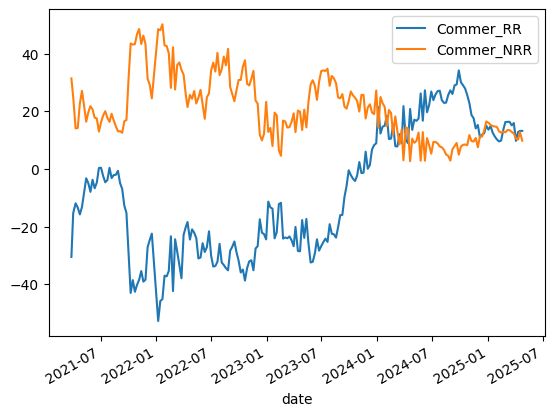

In [100]:
(dfs['DEBM'][['Commer_RR', 'Commer_NRR']]-dfs['F7BM'][['Commer_RR', 'Commer_NRR']]).plot()

In [109]:
import refinitiv.data as rd
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [223]:
rd.open_session()
power = rd.get_history(['DEBYF6'],count=500)
power = power[['TRDPRC_1', 'OPINT_1', 'ACVOL_UNS']].copy()
power.columns = ['power', 'oi', 'vol']
gas = rd.get_history(['TFMBYZ6'], count=500)
gas = gas[['TRDPRC_1']].copy()
gas.columns = ['gas']
eua = rd.get_history(['CFI2Z6'],count=500)
eua = eua[['TRDPRC_1']].copy()
eua.columns = ['eua']
rd.close_session()

c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

In [224]:
raw = pd.concat([power, gas, eua],axis=1)
raw['price'] = raw['power'] / (raw['gas'] + raw['eua'] * 0.2)
# raw['price'] = raw['power']
raw = raw[['price', 'oi', 'vol']].dropna()

In [212]:
raw = pd.concat([power, gas, eua],axis=1)
raw['price'] = raw['power'] / (raw['gas'] + raw['eua'] * 0.2)
# raw['price'] = raw['power']
raw = raw[['price', 'oi', 'vol']].dropna()
df = raw.copy()
df['price_diff'] = df['price'].pct_change()
df['oi_diff'] = df['oi'].diff()
df['vol_trend'] = df['vol'].rolling(30).mean()
df['vol_div'] = df['vol'] / df['vol_trend'] - 1
df['oi_trend'] = df['oi_diff'].rolling(30).mean()
df['oi_div'] = df['oi_diff'] / df['oi_trend'] - 1
df.dropna(inplace=True)
df['hp_act'] = np.where(((df['price_diff']>0)&(df['oi_div']>0)),1,
                        np.where(((df['price_diff']<0)&(df['oi_div']>0)),-1,0))
df['hpi'] = df['hp_act'].rolling(30).mean()
df['hpi_weighted'] = df['hpi'] * df['vol_trend']
df.dropna(inplace=True)


In [4]:
import numpy as np
import pandas as pd
import refinitiv.data as rd

rd.open_session()
power = rd.get_history(['DEBYF6'],count=500)
power = power[['SETTLE', 'OPINT_1', 'ACVOL_UNS']].copy()
power.columns = ['power', 'oi', 'vol']
gas = rd.get_history(['TFMBYZ6'], count=500)
gas = gas[['SETTLE']].copy()
gas.columns = ['gas']
eua = rd.get_history(['CFI2Z6'],count=500)
eua = eua[['SETTLE']].copy()
eua.columns = ['eua']
rd.close_session()


LOOKBACK = 30       # window for ‘normal’ activity
VOL_CAP  = 3.0       # max multiple of normal vol that maps to 1.0

# ---------- 1. build the frame ----------
raw = pd.concat([power, gas, eua], axis=1)
raw["price"] = raw["power"] / (raw["gas"] + 0.2 * raw["eua"])   # or raw['power']
# raw['price'] = raw['power']
df = raw[["price", "oi", "vol"]].dropna().copy()

# ---------- 2. daily changes & deviations ----------
df["price_diff"] = df["price"].pct_change()

# OI deviation (% of its 30-day mean) – stable even if the mean drifts upward
oi_mean          = df["oi"].rolling(LOOKBACK).mean()
df["oi_dev"]     = (df["oi"] - oi_mean)         # −0.01 … +∞

# Volume deviation (× of its 30-day mean) rescaled to 0–1
vol_mean         = df["vol"].rolling(LOOKBACK).mean()
vol_mult         = ((df["vol"] - vol_mean)/vol_mean).clip(upper=VOL_CAP)   # 1 … VOL_CAP
df["vol_idx"]    = ((vol_mult - 1) / (VOL_CAP - 1)).rolling(LOOKBACK).mean()               # 0 … 1
df = df.dropna()
# ---------- 3. core hedging-direction flag ----------
df["hp_act"] = np.where(
    (df["price_diff"] > 0) & (df["oi_dev"] > 0),  1,         # buyer hedging
    np.where(
        (df["price_diff"] < 0) & (df["oi_dev"] > 0), -1,     # producer hedging
        0                                                    # otherwise
    )
)

# ---------- 4. rolling hedging-pressure index ----------
df["hpi"] = df["hp_act"].rolling(LOOKBACK).mean()

# ---------- 5. weight by scaled volume (0–1) ----------
df["hpi_weighted"] = df["hpi"]

df.dropna(inplace=True)


c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

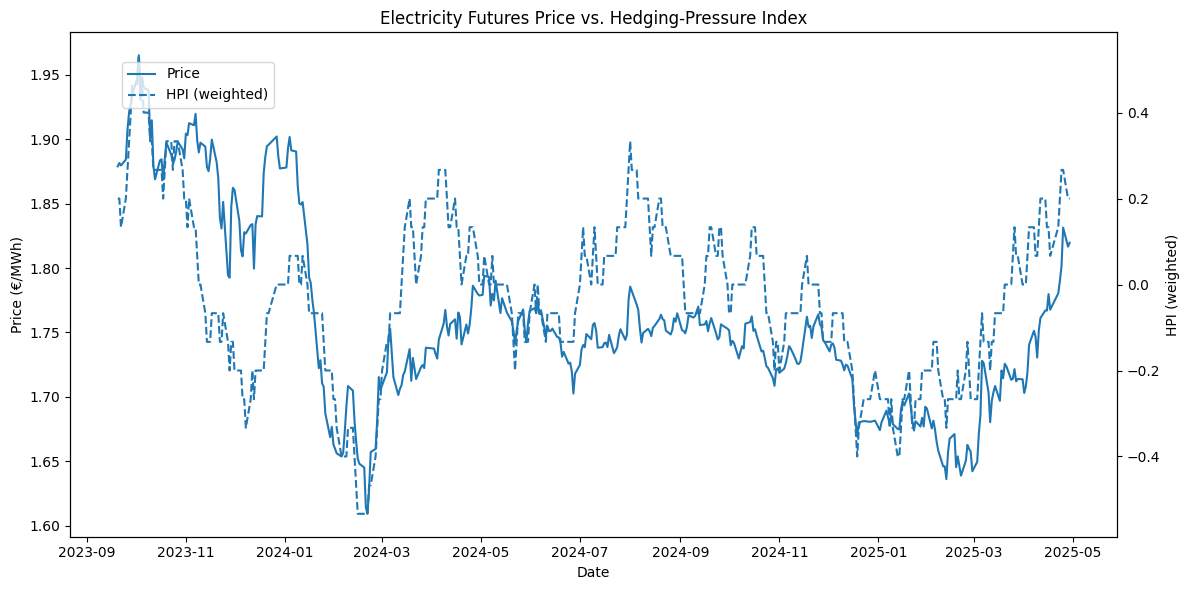

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# assuming 'df' DataFrame already exists in the notebook scope
# and contains columns 'price' and 'hpi_weighted'

fig, ax1 = plt.subplots(figsize=(12, 6))

# Price on left y‑axis
ax1.plot(df.index, df["price"], label="Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (€/MWh)")
ax1.tick_params(axis="y")

# HPI on right y‑axis
ax2 = ax1.twinx()
ax2.plot(df.index, df["hpi_weighted"], label="HPI (weighted)", linestyle="--")
ax2.set_ylabel("HPI (weighted)")
ax2.tick_params(axis="y")

# Titles & legend
plt.title("Electricity Futures Price vs. Hedging‑Pressure Index")
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.show()


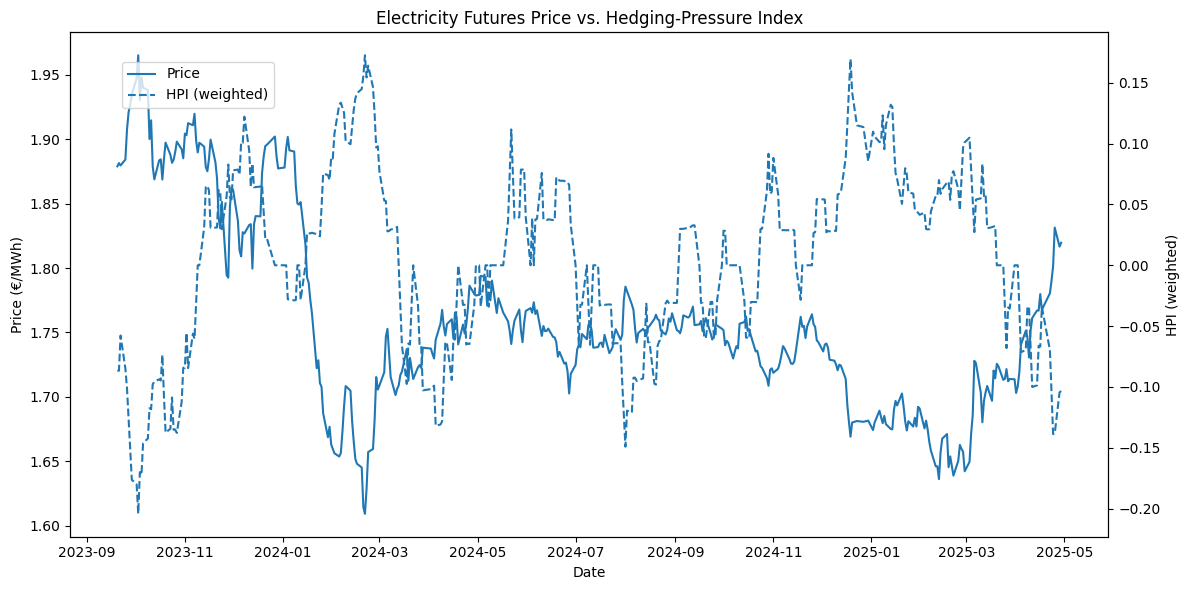

In [278]:
import pandas as pd
import matplotlib.pyplot as plt

# assuming 'df' DataFrame already exists in the notebook scope
# and contains columns 'price' and 'hpi_weighted'

fig, ax1 = plt.subplots(figsize=(12, 6))

# Price on left y‑axis
ax1.plot(df.index, df["price"], label="Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (€/MWh)")
ax1.tick_params(axis="y")

# HPI on right y‑axis
ax2 = ax1.twinx()
ax2.plot(df.index, df["hpi_weighted"], label="HPI (weighted)", linestyle="--")
ax2.set_ylabel("HPI (weighted)")
ax2.tick_params(axis="y")

# Titles & legend
plt.title("Electricity Futures Price vs. Hedging‑Pressure Index")
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.show()


In [279]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# helper: fitted value at the last point of a rolling window
# ------------------------------------------------------------
def rolling_lin_trend(arr):
    """
    arr : 1-D numpy array of length LOOKBACK
    returns the fitted ŷ at the right-edge point
    """
    x = np.arange(len(arr))
    slope, intercept = np.polyfit(x, arr, 1)
    return intercept + slope * x[-1]          # ŷ at last x

LOOKBACK = 30
VOL_CAP  = 3.0

# ---------- 1. fetch & build the frame (unchanged) ----------
raw = pd.concat([power, gas, eua], axis=1)
raw["price"] = raw["power"] / (raw["gas"] + 0.2 * raw["eua"])
df = raw[["price", "oi", "vol"]].dropna().copy()

# ---------- 2. daily changes & “trend” deviations ----------
df["price_diff"] = df["price"].pct_change()

# rolling linear trend for OI
df["oi_trend"] = (
    df["oi"]
    .rolling(LOOKBACK, min_periods=LOOKBACK)
    .apply(rolling_lin_trend, raw=True)
)

df["oi_dev"] = (df["oi"] - df["oi_trend"]) 

# rolling linear trend for volume
df["vol_trend"] = (
    df["vol"]
    .rolling(LOOKBACK, min_periods=LOOKBACK)
    .apply(rolling_lin_trend, raw=True)
)

# Volume deviation (× of its 30-day mean) rescaled to 0–1
vol_mean         = df["vol"].rolling(LOOKBACK).mean()
vol_mult         = ((df["vol"] - df['vol_trend'])/df['vol_trend']).clip(upper=VOL_CAP)   # 1 … VOL_CAP
df["vol_idx"]    = ((vol_mult - 1) / (VOL_CAP - 1)).rolling(LOOKBACK).mean()                        # 0 … 1

df = df.dropna()

# ---------- 3. core hedging-direction flag (unchanged) ----------
df["hp_act"] = np.where(
    (df["price_diff"] > 0) & (df["oi_dev"] > 0),  1,
    np.where(
        (df["price_diff"] < 0) & (df["oi_dev"] > 0), -1,
        0
    )
)

# ---------- 4. hedging-pressure index ----------
df["hpi"] = df["hp_act"].rolling(LOOKBACK).mean()

# ---------- 5. weight by scaled volume index ----------
df["hpi_weighted"] = df["hpi"] * df["vol_idx"]

df.dropna(inplace=True)


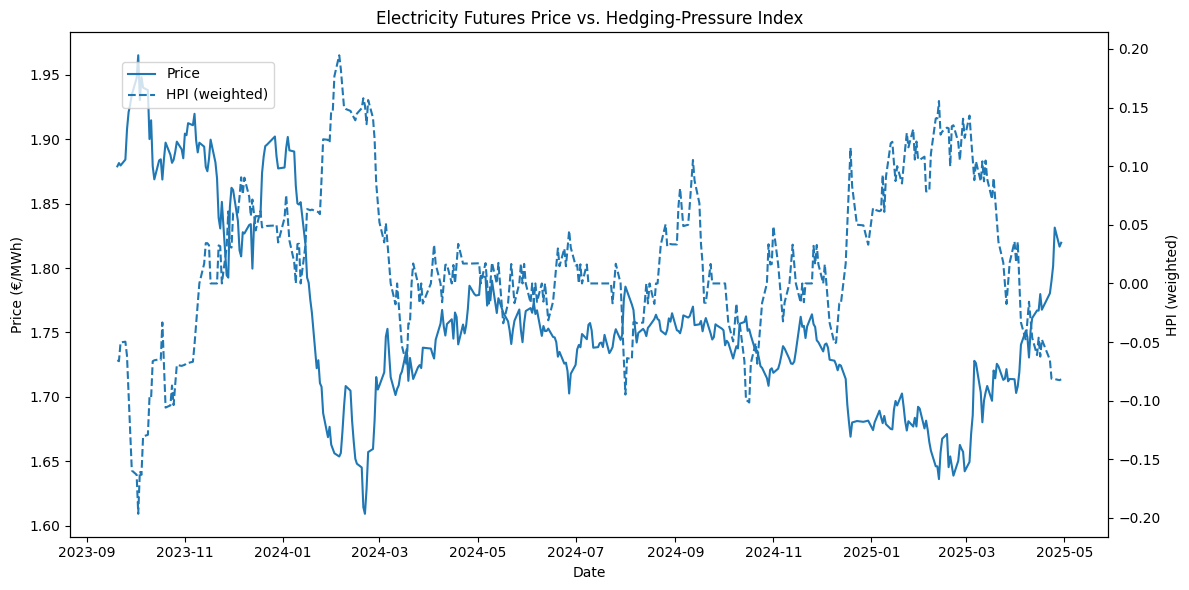

In [281]:
import pandas as pd
import matplotlib.pyplot as plt

# assuming 'df' DataFrame already exists in the notebook scope
# and contains columns 'price' and 'hpi_weighted'

fig, ax1 = plt.subplots(figsize=(12, 6))

# Price on left y‑axis
ax1.plot(df.index, df["price"], label="Price")
ax1.set_xlabel("Date")
ax1.set_ylabel("Price (€/MWh)")
ax1.tick_params(axis="y")

# HPI on right y‑axis
ax2 = ax1.twinx()
ax2.plot(df.index, df["hpi_weighted"], label="HPI (weighted)", linestyle="--")
ax2.set_ylabel("HPI (weighted)")
ax2.tick_params(axis="y")

# Titles & legend
plt.title("Electricity Futures Price vs. Hedging‑Pressure Index")
fig.tight_layout()
fig.legend(loc="upper left", bbox_to_anchor=(0.1, 0.9))

plt.show()


In [293]:
import numpy as np
import pandas as pd

# -------- fetch (unchanged) ---------------------------------------
rd.open_session()
power = rd.get_history(['DEBYF6'], count=500).loc[:, ['SETTLE','OPINT_1','ACVOL_UNS']]
power.columns = ['power', 'oi', 'vol']

gas  = rd.get_history(['TFMBYZ6'], count=500)[['SETTLE']].rename(columns={'SETTLE':'gas'})
eua  = rd.get_history(['CFI2Z6' ], count=500)[['SETTLE']].rename(columns={'SETTLE':'eua'})
rd.close_session()

# -------- build working frame -------------------------------------
raw         = pd.concat([power, gas, eua], axis=1)
raw['price'] = raw['power'] / (raw['gas'] + 0.2 * raw['eua'])   # or raw['power']
df          = raw[['price', 'oi', 'vol']].dropna().copy()

df['price_diff'] = df['price'].pct_change()

# -------- helper to compute one HPI given a look-back -------------
def hpi_weighted(frame: pd.DataFrame, window: int, vol_cap: float = 3.0):
    # ------------- rolling trend baselines ---------------------------
    oi_mean  = frame['oi'].rolling(window).mean()
    vol_mean = frame['vol'].rolling(window).mean()

    oi_dev   = frame['oi'] - oi_mean
    vol_mult = ((frame['vol'] - vol_mean) / vol_mean).clip(upper=vol_cap)
    vol_idx  = ((vol_mult - 1) / (vol_cap - 1)).rolling(window).mean()          # 0 … 1   (can be NaN)

    # ------------- hedging-direction flag ----------------------------
    cond_up =  ((frame['price_diff'] > 0) & (oi_dev > 0)).fillna(False).to_numpy()
    cond_dn =  ((frame['price_diff'] < 0) & (oi_dev > 0)).fillna(False).to_numpy()

    hp_act  = np.select([cond_up, cond_dn], [1, -1], default=0)

    # ------------- rolling mean & volume weighting -------------------
    hpi        = pd.Series(hp_act, index=frame.index).rolling(window).mean()
    hpi_weight = hpi * vol_idx                 # vol_idx already aligned

    return hpi_weight


df = df.dropna()
# -------- generate both indices -----------------------------------
df['hpi_w30'] = hpi_weighted(df, 40)
df['hpi_w60'] = hpi_weighted(df, 50)

df.dropna(inplace=True)

# df now contains:
#   hpi_w30  – 30-day weighted hedging-pressure index
#   hpi_w60  – 60-day weighted hedging-pressure index


c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

In [312]:


def hpi_weighted(frame: pd.DataFrame, window: int, vol_cap: float = 3.0):
    # ------------- rolling trend baselines ---------------------------
    oi_mean  = frame['oi'].rolling(window).mean()
    vol_mean = frame['vol'].rolling(window).mean()

    oi_dev   = frame['oi'] - oi_mean
    vol_mult = ((frame['vol'] - vol_mean) / vol_mean).clip(upper=vol_cap)
    vol_idx  = ((vol_mult - 1) / (vol_cap - 1)).rolling(window).mean()          # 0 … 1   (can be NaN)

    # ------------- hedging-direction flag ----------------------------
    cond_up =  ((frame['price_diff'] > 0) & (oi_dev > 0)).fillna(False).to_numpy()
    cond_dn =  ((frame['price_diff'] < 0) & (oi_dev > 0)).fillna(False).to_numpy()

    hp_act  = np.select([cond_up, cond_dn], [1, -1], default=0)

    # ------------- rolling mean & volume weighting -------------------
    hpi        = pd.Series(hp_act, index=frame.index).rolling(window).mean()
    hpi_weight = hpi * vol_idx                 # vol_idx already aligned

    return hpi_weight


c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

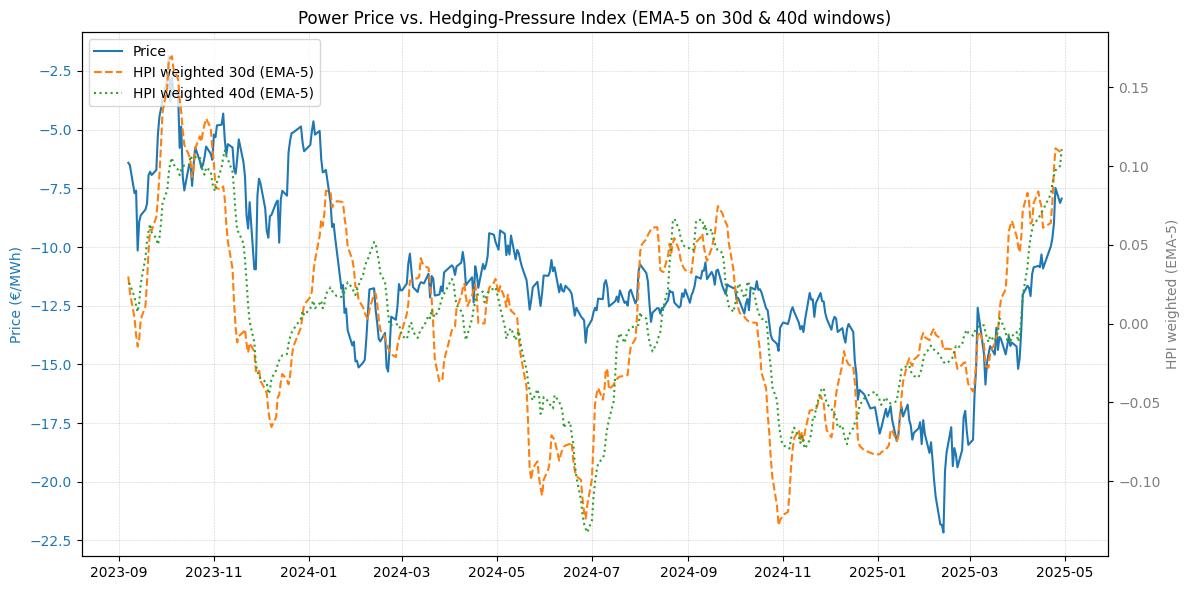

In [317]:
import numpy as np
import pandas as pd

# ------------------- parameters you can test -------------------------
FAST_WINDOW = 30        # e.g. 20, 30 …
SLOW_WINDOW = 40        # e.g. 60, 90 …
VOL_CAP     = 3       # >-normal volume that maps to vol_idx = 1

# ------------------- data fetch / prep (unchanged) -------------------
rd.open_session()
power = rd.get_history(['DEBYF6'], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
power.columns = ['power','oi','vol']
gas   = rd.get_history(['TFMBYZ6'], count=500)[['SETTLE']].rename(columns={'SETTLE':'gas'})
eua   = rd.get_history(['CFI2Z6' ], count=500)[['SETTLE']].rename(columns={'SETTLE':'eua'})
rd.close_session()

raw          = pd.concat([power, gas, eua], axis=1)
raw['price'] = raw['power'] / (raw['gas'] + 0.2 * raw['eua'])
raw['price'] = raw['power'] - raw['gas']*2 - raw['eua']*0.4
df           = raw[['price','oi','vol']].dropna().copy()
df['price_diff'] = df['price'].pct_change()

# ------------------- compute fast & slow indices ---------------------
df['hpi_fast'] = hpi_weighted(df, FAST_WINDOW, VOL_CAP)
df['hpi_slow'] = hpi_weighted(df, SLOW_WINDOW, VOL_CAP)
df.dropna(inplace=True)

# --- 5-period EMA smoothing -----------------------------------------
df['hpi_fast_ema'] = df['hpi_fast'].ewm(span=5, adjust=False).mean()
df['hpi_slow_ema'] = df['hpi_slow'].ewm(span=5, adjust=False).mean()

# --- plot ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# price (left axis)
ax1.plot(df.index, df['price'], label='Price', color='tab:blue')
ax1.set_ylabel('Price (€/MWh)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# grid on primary axis (covers both axes)
ax1.grid(which='both', axis='both', linestyle='--', linewidth=0.4, alpha=0.6)

# smoothed HPIs (right axis)
ax2 = ax1.twinx()
ax2.plot(df.index, df['hpi_fast_ema'], '--',
         label=f'HPI weighted {FAST_WINDOW}d (EMA-5)', color='tab:orange')
ax2.plot(df.index, df['hpi_slow_ema'], ':',
         label=f'HPI weighted {SLOW_WINDOW}d (EMA-5)', color='tab:green')
ax2.set_ylabel('HPI weighted (EMA-5)', color='tab:gray')
ax2.tick_params(axis='y', labelcolor='tab:gray')

# combined legend
handles, labels = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(handles + h2, labels + l2, loc='upper left')

plt.title(f'Power Price vs. Hedging-Pressure Index '
          f'(EMA-5 on {FAST_WINDOW}d & {SLOW_WINDOW}d windows)')
plt.tight_layout()
plt.show()


c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

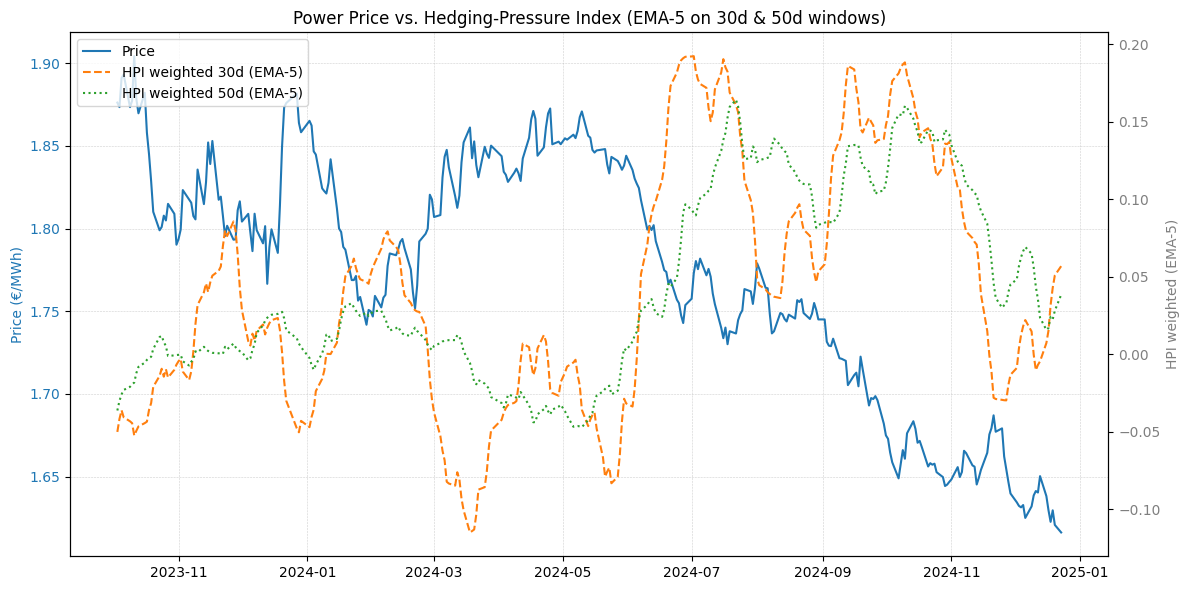

In [ ]:
import numpy as np
import pandas as pd

# ------------------- parameters you can test -------------------------
FAST_WINDOW = 30        # e.g. 20, 30 …
SLOW_WINDOW = 50        # e.g. 60, 90 …
VOL_CAP     = 3       # >-normal volume that maps to vol_idx = 1

# ------------------- data fetch / prep (unchanged) -------------------
rd.open_session()
power = rd.get_history(['DEBYF5^2'], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
power.columns = ['power','oi','vol']
gas   = rd.get_history(['TFMBYZ5^2'], count=500)[['SETTLE']].rename(columns={'SETTLE':'gas'})
eua   = rd.get_history(['CFI2Z5' ], count=500)[['SETTLE']].rename(columns={'SETTLE':'eua'})
rd.close_session()

raw          = pd.concat([power, gas, eua], axis=1)
raw['price'] = raw['power'] / (raw['gas'] + 0.2 * raw['eua'])
df           = raw[['price','oi','vol']].dropna().copy()
df['price_diff'] = df['price'].pct_change()

# ------------------- compute fast & slow indices ---------------------
df['hpi_fast'] = hpi_weighted(df, FAST_WINDOW, VOL_CAP)
df['hpi_slow'] = hpi_weighted(df, SLOW_WINDOW, VOL_CAP)
df.dropna(inplace=True)

# --- 5-period EMA smoothing -----------------------------------------
df['hpi_fast_ema'] = df['hpi_fast'].ewm(span=5, adjust=False).mean()
df['hpi_slow_ema'] = df['hpi_slow'].ewm(span=5, adjust=False).mean()

# --- plot ------------------------------------------------------------
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(12, 6))

# price (left axis)
ax1.plot(df.index, df['price'], label='Price', color='tab:blue')
ax1.set_ylabel('Price (€/MWh)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# grid on primary axis (covers both axes)
ax1.grid(which='both', axis='both', linestyle='--', linewidth=0.4, alpha=0.6)

# smoothed HPIs (right axis)
ax2 = ax1.twinx()
ax2.plot(df.index, df['hpi_fast_ema'], '--',
         label=f'HPI weighted {FAST_WINDOW}d (EMA-5)', color='tab:orange')
ax2.plot(df.index, df['hpi_slow_ema'], ':',
         label=f'HPI weighted {SLOW_WINDOW}d (EMA-5)', color='tab:green')
ax2.set_ylabel('HPI weighted (EMA-5)', color='tab:gray')
ax2.tick_params(axis='y', labelcolor='tab:gray')

# combined legend
handles, labels = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(handles + h2, labels + l2, loc='upper left')

plt.title(f'Power Price vs. Hedging-Pressure Index '
          f'(EMA-5 on {FAST_WINDOW}d & {SLOW_WINDOW}d windows)')
plt.tight_layout()
plt.show()


In [322]:
LEG1['power']

'DEBYF5^2'

c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

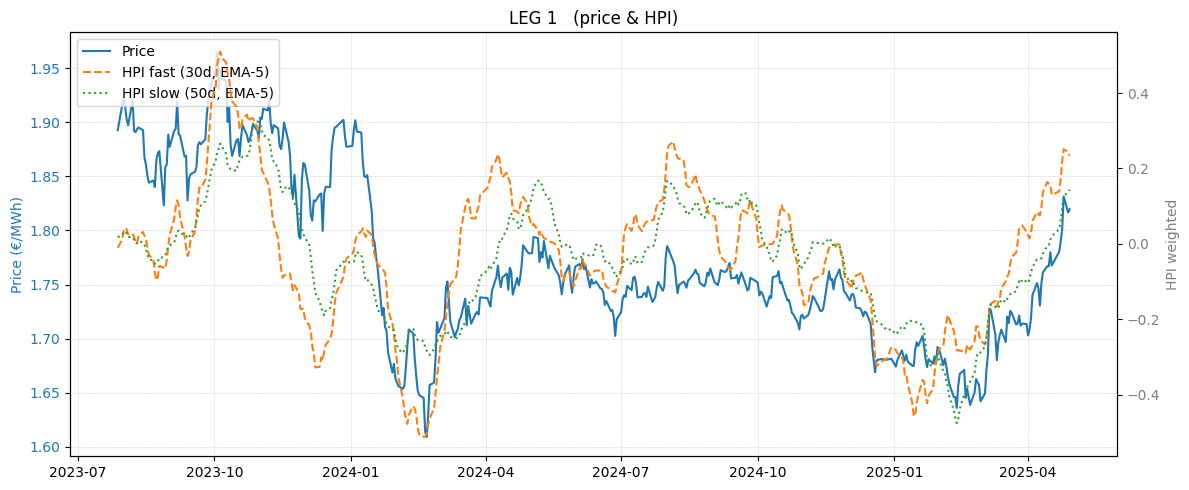

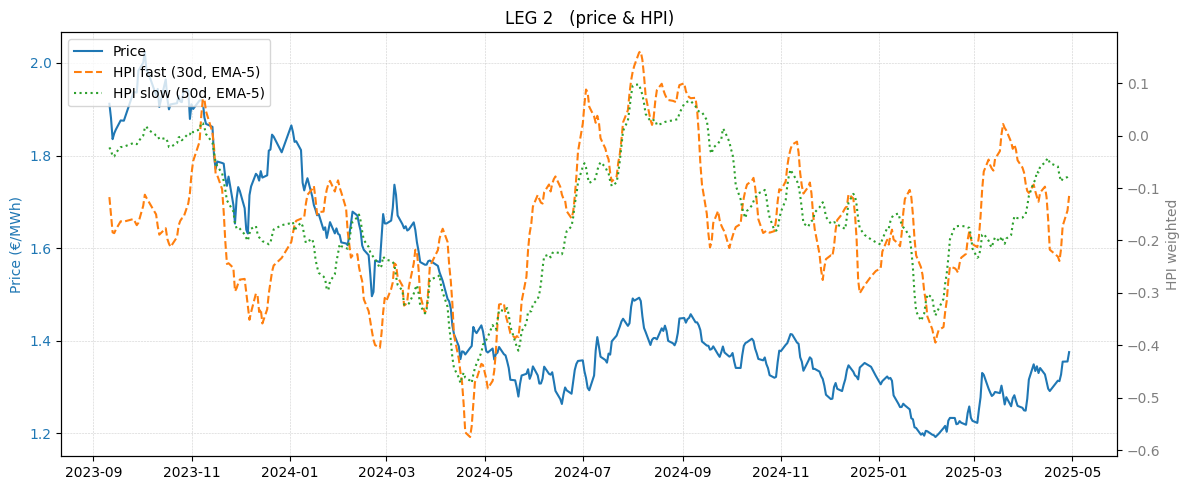

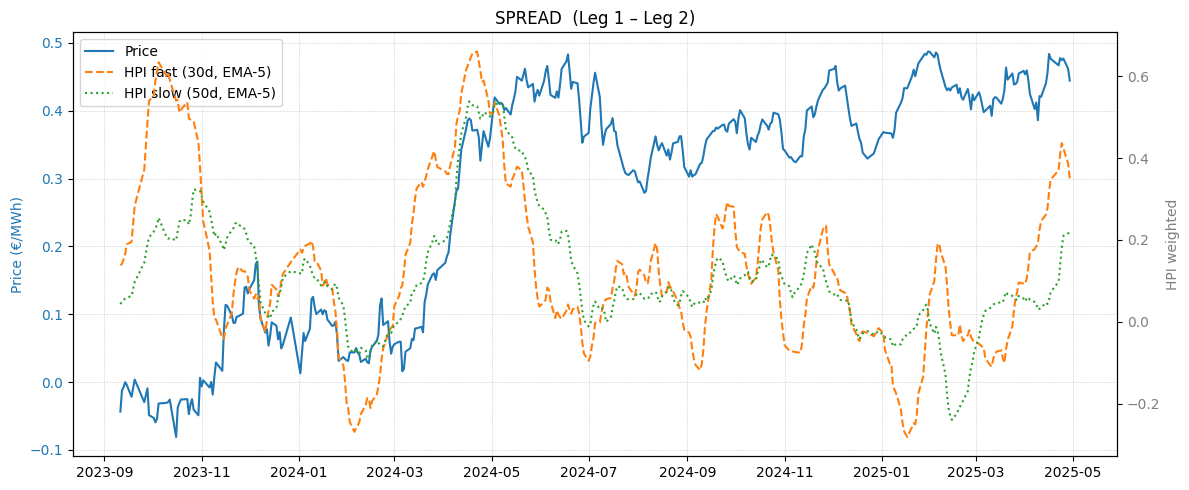

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import refinitiv.data as rd

# --------------------------------------------------------------------
# CONFIGURATION – set the two legs you want to compare
# --------------------------------------------------------------------
LEG1 = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG2 = dict(power='F7BYF6', gas='TFMBYZ6', eua='CFI2Z6')

FAST_WINDOW = 30
SLOW_WINDOW = 50
VOL_CAP     = 2
EMA_SPAN    = 5

# --------------------------------------------------------------------
# HELPER – weighted HPI for any DataFrame + look-back
# --------------------------------------------------------------------
def hpi_weighted(frame: pd.DataFrame, window: int, vol_cap: float = 3.0):
    oi_mean  = frame['oi'].rolling(window).mean()
    vol_mean = frame['vol'].rolling(window).mean()
    vol_half_mean = frame['vol'].rolling(int(window/2)).mean()

    oi_dev   = frame['oi'] - oi_mean
    vol_mult = ((vol_half_mean/vol_mean)).clip(upper=vol_cap)
    # vol_idx  = ((vol_mult - 1) / (vol_cap - 1)).rolling(window).mean()

    cond_up = ((frame['price_diff'] > 0) & (oi_dev > 0)).fillna(False).to_numpy()
    cond_dn = ((frame['price_diff'] < 0) & (oi_dev > 0)).fillna(False).to_numpy()
    hp_act  = np.select([cond_up, cond_dn], [1, -1], default=0)

    hpi = pd.Series(hp_act, index=frame.index).rolling(window).mean()
    return hpi * vol_mult

# --------------------------------------------------------------------
# FUNCTION – download one leg → DataFrame with price & HPIs
# --------------------------------------------------------------------
def fetch_leg(codes: dict):
    rd.open_session()
    pwr = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    pwr.columns = ['power','oi','vol']
    gas = rd.get_history([codes['gas']], count=500)[['SETTLE']].rename(columns={'SETTLE':'gas'})
    eua = rd.get_history([codes['eua']], count=500)[['SETTLE']].rename(columns={'SETTLE':'eua'})
    rd.close_session()

    raw          = pd.concat([pwr, gas, eua], axis=1)
    raw['price'] = raw['power'] / (raw['gas'] + 0.2 * raw['eua'])
    raw['price_raw'] = raw['power']
    df           = raw[['price','oi','vol', 'price_raw']].dropna().copy()
    df['price_diff'] = df['price'].pct_change()

    df['hpi_fast'] = hpi_weighted(df, FAST_WINDOW, VOL_CAP)
    df['hpi_slow'] = hpi_weighted(df, SLOW_WINDOW, VOL_CAP)
    df['hpi_fast_ema'] = df['hpi_fast'].ewm(span=EMA_SPAN, adjust=False).mean()
    df['hpi_slow_ema'] = df['hpi_slow'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()

leg1_df = fetch_leg(LEG1)
leg2_df = fetch_leg(LEG2)

# --------------------------------------------------------------------
# SPREAD – price difference & HPI difference
# --------------------------------------------------------------------
spread = pd.DataFrame(index=leg1_df.index.intersection(leg2_df.index))
spread['price'] = leg1_df['price'] - leg2_df['price']
spread['hpi_fast_ema'] = leg1_df['hpi_fast_ema'] - leg2_df['hpi_fast_ema']
spread['hpi_slow_ema'] = leg1_df['hpi_slow_ema'] - leg2_df['hpi_slow_ema']

# --------------------------------------------------------------------
# PLOTTER – one figure per series
# --------------------------------------------------------------------
def plot_leg(df, title):
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(df.index, df['price'], color='tab:blue', label='Price')
    ax1.set_ylabel('Price (€/MWh)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(which='both', linestyle='--', linewidth=0.4, alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['hpi_fast_ema'], '--', color='tab:orange',
             label=f'HPI fast ({FAST_WINDOW}d, EMA-{EMA_SPAN})')
    ax2.plot(df.index, df['hpi_slow_ema'], ':',  color='tab:green',
             label=f'HPI slow ({SLOW_WINDOW}d, EMA-{EMA_SPAN})')
    ax2.set_ylabel('HPI weighted', color='tab:gray')
    ax2.tick_params(axis='y', labelcolor='tab:gray')

    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_leg(leg1_df, 'LEG 1   (price & HPI)')
plot_leg(leg2_df, 'LEG 2   (price & HPI)')
plot_leg(spread , 'SPREAD  (Leg 1 – Leg 2)')


In [24]:
test = df[['oi', 'vol']].astype(float)
test['oi_diff'] = test['oi'].diff()
test = test.dropna()
test['test'] = test['oi_diff'] > test['vol']
test['vol_to_oi'] = (test['oi_diff']/test['vol']).clip(lower=0)
test.mean()

oi           23142.278325
vol            332.524631
oi_diff        151.842365
test             0.000000
vol_to_oi        0.514565
dtype: float64

In [21]:
test.loc[test['vol_to_oi']==test['vol_to_oi'].min()]

,oi,vol,oi_diff,test,vol_to_oi
Date,,,,,
2023-12-29,7775.0,10.0,-20.0,False,-2.0


In [23]:
test.loc[pd.to_datetime('2023-12-20'):pd.to_datetime('2024-01-05')]

,oi,vol,oi_diff,test,vol_to_oi
Date,,,,,
2023-12-20,7618.0,77.0,9.0,False,0.116883
2023-12-21,7699.0,132.0,81.0,False,0.613636
2023-12-22,7728.0,60.0,29.0,False,0.483333
2023-12-27,7779.0,64.0,51.0,False,0.796875
2023-12-28,7795.0,29.0,16.0,False,0.551724
2023-12-29,7775.0,10.0,-20.0,False,-2.000000
2024-01-02,7817.0,47.0,42.0,False,0.893617
2024-01-03,7837.0,22.0,20.0,False,0.909091
2024-01-04,7880.0,57.0,43.0,False,0.754386


<Axes: xlabel='Date'>

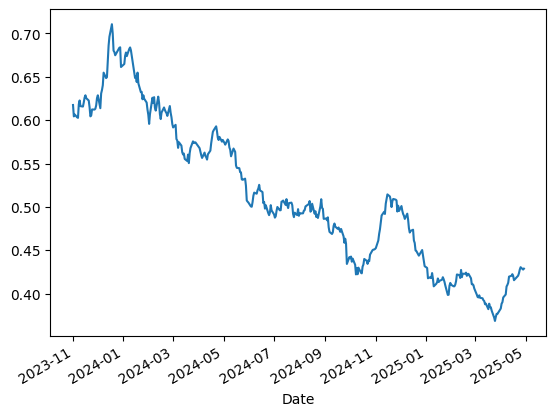

In [27]:
test['vol_to_oi'].rolling(30).mean().plot()

c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

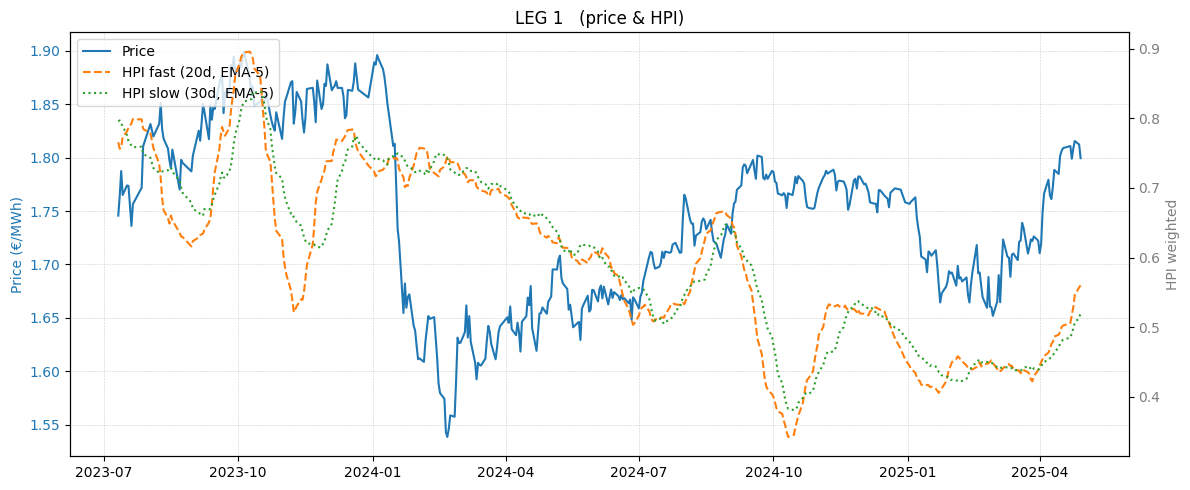

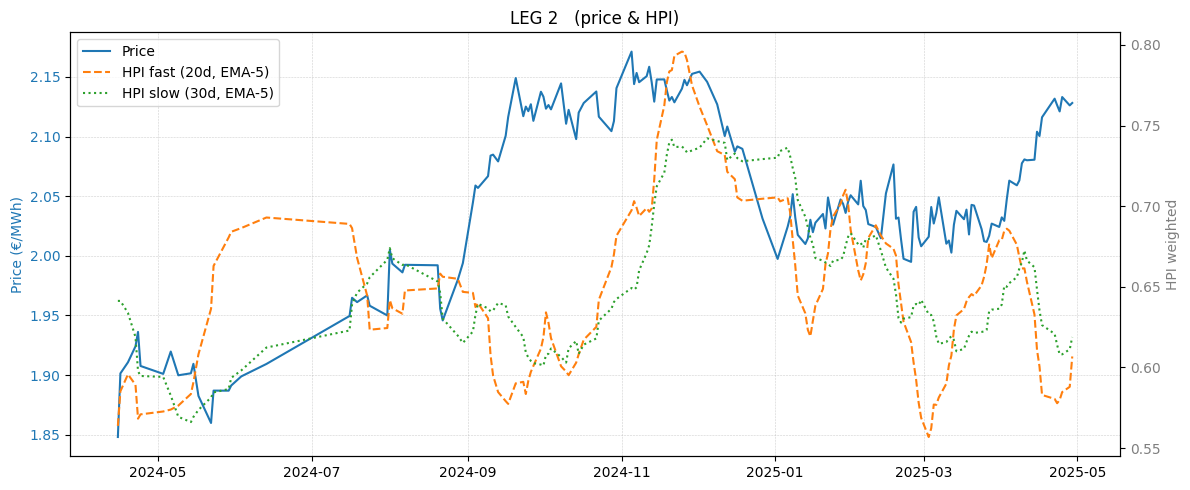

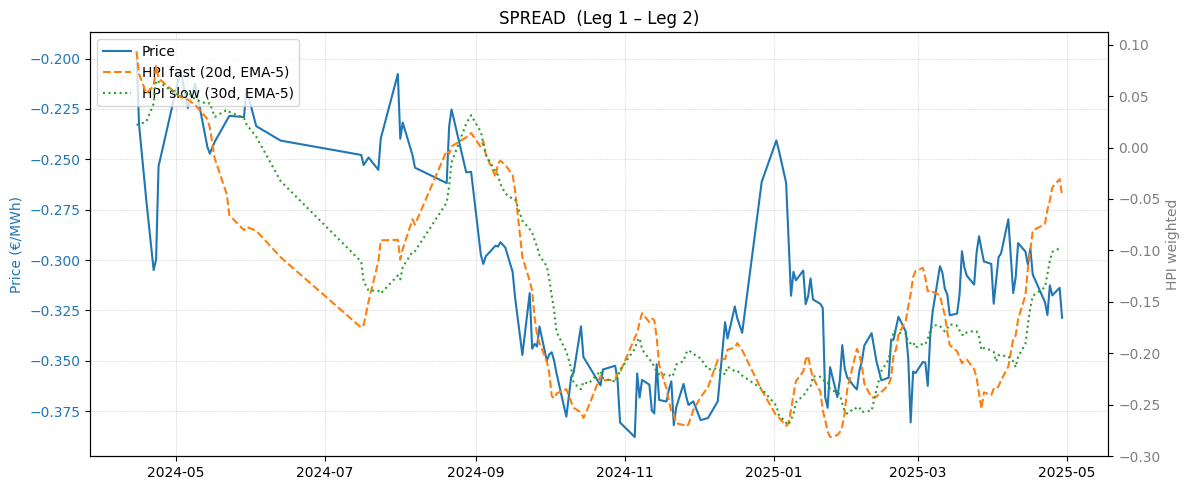

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import refinitiv.data as rd

# --------------------------------------------------------------------
# CONFIGURATION – set the two legs you want to compare
# --------------------------------------------------------------------
LEG1 = dict(power='DEBYF7', gas='TFMBYZ7', eua='CFI2Z7')
LEG2 = dict(power='FDBYF7', gas='TFMBYZ7', eua='CFI2Z7')

FAST_WINDOW = 20
SLOW_WINDOW = 30
VOL_CAP     = 2
EMA_SPAN    = 5

# --------------------------------------------------------------------
# HELPER – weighted HPI for any DataFrame + look-back
# --------------------------------------------------------------------
def hpi_weighted(frame: pd.DataFrame, window: int):
    frame['oi_diff'] = frame['oi'].diff()
    

    oi_ratio   = (frame['oi_diff']/frame['vol']).clip(lower=0)
    

    cond_up = ((frame['price_diff'] > 0) & (oi_ratio > 0.5)).fillna(False).to_numpy()
    cond_dn = ((frame['price_diff'] < 0) & (oi_ratio < 0.5)).fillna(False).to_numpy()
    hp_act  = np.select([cond_up, cond_dn], [1, -1], default=0)

    hpi = pd.Series(hp_act, index=frame.index).rolling(window).mean()
    return hpi

# --------------------------------------------------------------------
# FUNCTION – download one leg → DataFrame with price & HPIs
# --------------------------------------------------------------------
def fetch_leg(codes: dict):
    rd.open_session()
    pwr = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    pwr.columns = ['power','oi','vol']
    gas = rd.get_history([codes['gas']], count=500)[['SETTLE']].rename(columns={'SETTLE':'gas'})
    eua = rd.get_history([codes['eua']], count=500)[['SETTLE']].rename(columns={'SETTLE':'eua'})
    rd.close_session()

    raw          = pd.concat([pwr, gas, eua], axis=1)
    raw['price'] = raw['power'] / (raw['gas'] + 0.2 * raw['eua'])
    raw['price_raw'] = raw['power']
    df           = raw[['price','oi','vol', 'price_raw']].dropna().copy()
    df['price_diff'] = df['price'].pct_change()

    df['hpi_fast'] = hpi_weighted(df, FAST_WINDOW)
    df['hpi_slow'] = hpi_weighted(df, SLOW_WINDOW)
    df['hpi_fast_ema'] = df['hpi_fast'].ewm(span=EMA_SPAN, adjust=False).mean()
    df['hpi_slow_ema'] = df['hpi_slow'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()

leg1_df = fetch_leg(LEG1)
leg2_df = fetch_leg(LEG2)

# --------------------------------------------------------------------
# SPREAD – price difference & HPI difference
# --------------------------------------------------------------------
spread = pd.DataFrame(index=leg1_df.index.intersection(leg2_df.index))
spread['price'] = leg1_df['price'] - leg2_df['price']
spread['hpi_fast_ema'] = leg1_df['hpi_fast_ema'] - leg2_df['hpi_fast_ema']
spread['hpi_slow_ema'] = leg1_df['hpi_slow_ema'] - leg2_df['hpi_slow_ema']

# --------------------------------------------------------------------
# PLOTTER – one figure per series
# --------------------------------------------------------------------
def plot_leg(df, title):
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(df.index, df['price'], color='tab:blue', label='Price')
    ax1.set_ylabel('Price (€/MWh)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(which='both', linestyle='--', linewidth=0.4, alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['hpi_fast_ema'], '--', color='tab:orange',
             label=f'HPI fast ({FAST_WINDOW}d, EMA-{EMA_SPAN})')
    ax2.plot(df.index, df['hpi_slow_ema'], ':',  color='tab:green',
             label=f'HPI slow ({SLOW_WINDOW}d, EMA-{EMA_SPAN})')
    ax2.set_ylabel('HPI weighted', color='tab:gray')
    ax2.tick_params(axis='y', labelcolor='tab:gray')

    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_leg(leg1_df, 'LEG 1   (price & HPI)')
plot_leg(leg2_df, 'LEG 2   (price & HPI)')
plot_leg(spread , 'SPREAD  (Leg 1 – Leg 2)')



c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

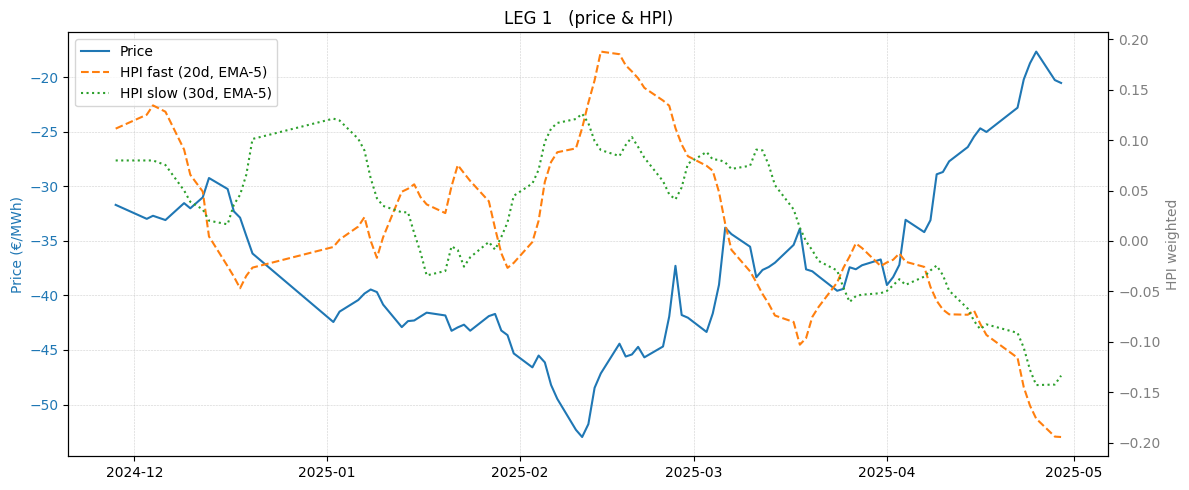

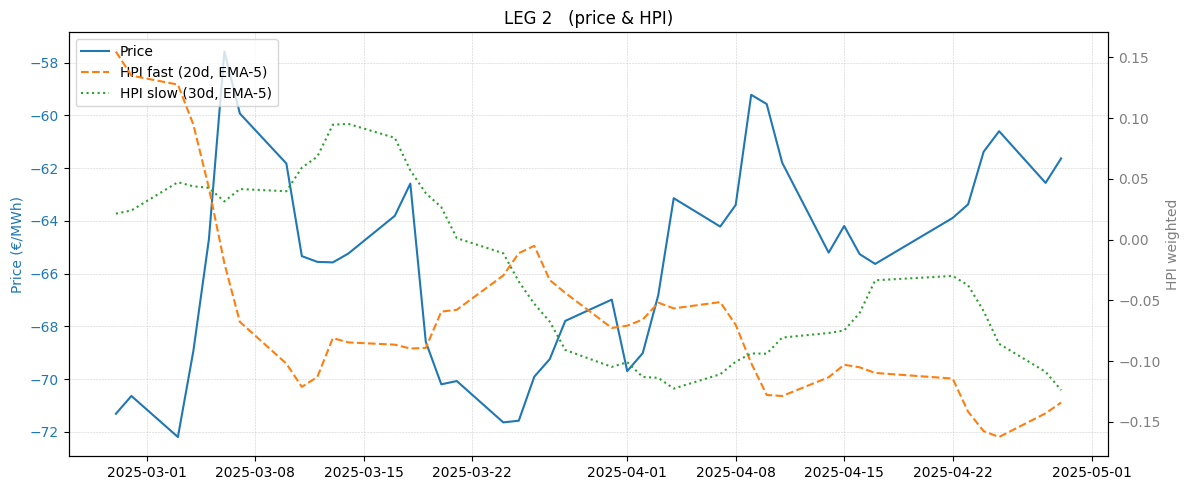

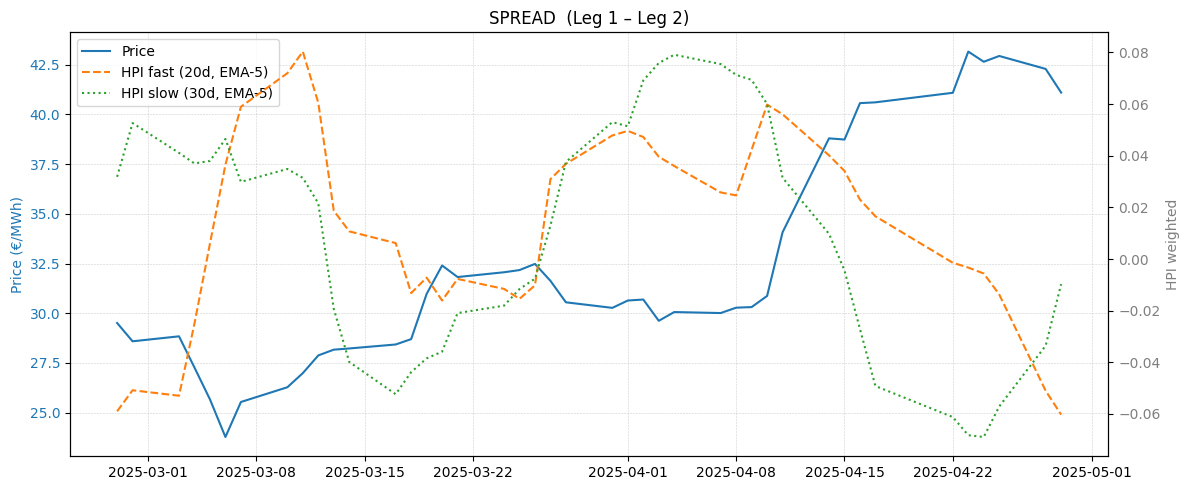

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import refinitiv.data as rd

# --------------------------------------------------------------------
# CONFIGURATION – set the two legs you want to compare
# --------------------------------------------------------------------
LEG1 = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG2 = dict(power='F7BYF6', gas='TFMBYZ6', eua='CFI2Z6')

LEG1 = dict(power='DEBMK5', gas='TFMBMK5', eua='CFI2Z5')
LEG2 = dict(power='F7BMK5', gas='TFMBMK5', eua='CFI2Z5')

LEG1 = dict(power='DEBMM5', gas='TFMBMM5', eua='CFI2Z5')
LEG2 = dict(power='F7BMM5', gas='TFMBMM5', eua='CFI2Z5')

FAST_WINDOW = 20
SLOW_WINDOW = 30
VOL_CAP     = 2
EMA_SPAN    = 5

# --------------------------------------------------------------------
# HELPER – weighted HPI for any DataFrame + look-back
# --------------------------------------------------------------------
def hpi_weighted(frame: pd.DataFrame, window: int):
    frame['oi_diff'] = frame['oi'].diff()
    

    oi_ratio   = (frame['oi_diff']/frame['vol']).clip(lower=0, upper=1)
    

    cond_up = ((frame['price_diff'] > 0)).fillna(False).to_numpy()
    cond_dn = ((frame['price_diff'] < 0)).fillna(False).to_numpy()
    hp_act  = np.select([cond_up, cond_dn], [1, -1], default=0)

    hp_act = hp_act * oi_ratio

    hpi = pd.Series(hp_act, index=frame.index).rolling(window).mean()
    return hpi

# --------------------------------------------------------------------
# FUNCTION – download one leg → DataFrame with price & HPIs
# --------------------------------------------------------------------
def fetch_leg(codes: dict):
    rd.open_session()
    pwr = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    pwr.columns = ['power','oi','vol']
    gas = rd.get_history([codes['gas']], count=500)[['SETTLE']].rename(columns={'SETTLE':'gas'})
    eua = rd.get_history([codes['eua']], count=500)[['SETTLE']].rename(columns={'SETTLE':'eua'})
    rd.close_session()

    raw          = pd.concat([pwr, gas, eua], axis=1)
    raw['price'] = raw['power'] / (raw['gas'] + 0.2 * raw['eua'])
    raw['price'] = raw['power'] - raw['gas'] * 2 - raw['eua'] * 0.4
    raw['price_raw'] = raw['power']
    df           = raw[['price','oi','vol', 'price_raw']].dropna().copy()
    df['price_diff'] = df['price'].pct_change()

    df['hpi_fast'] = hpi_weighted(df, FAST_WINDOW)
    df['hpi_slow'] = hpi_weighted(df, SLOW_WINDOW)
    df['hpi_fast_ema'] = df['hpi_fast'].ewm(span=EMA_SPAN, adjust=False).mean()
    df['hpi_slow_ema'] = df['hpi_slow'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()

leg1_df = fetch_leg(LEG1)
leg2_df = fetch_leg(LEG2)

# --------------------------------------------------------------------
# SPREAD – price difference & HPI difference
# --------------------------------------------------------------------
spread = pd.DataFrame(index=leg1_df.index.intersection(leg2_df.index))
spread['price'] = leg1_df['price'] - leg2_df['price']
spread['hpi_fast_ema'] = leg1_df['hpi_fast_ema'] - leg2_df['hpi_fast_ema']
spread['hpi_slow_ema'] = leg1_df['hpi_slow_ema'] - leg2_df['hpi_slow_ema']

# --------------------------------------------------------------------
# PLOTTER – one figure per series
# --------------------------------------------------------------------
def plot_leg(df, title):
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(df.index, df['price'], color='tab:blue', label='Price')
    ax1.set_ylabel('Price (€/MWh)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(which='both', linestyle='--', linewidth=0.4, alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['hpi_fast_ema'], '--', color='tab:orange',
             label=f'HPI fast ({FAST_WINDOW}d, EMA-{EMA_SPAN})')
    ax2.plot(df.index, df['hpi_slow_ema'], ':',  color='tab:green',
             label=f'HPI slow ({SLOW_WINDOW}d, EMA-{EMA_SPAN})')
    ax2.set_ylabel('HPI weighted', color='tab:gray')
    ax2.tick_params(axis='y', labelcolor='tab:gray')

    h1,l1 = ax1.get_legend_handles_labels()
    h2,l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, loc='upper left')
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_leg(leg1_df, 'LEG 1   (price & HPI)')
plot_leg(leg2_df, 'LEG 2   (price & HPI)')
plot_leg(spread , 'SPREAD  (Leg 1 – Leg 2)')



c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

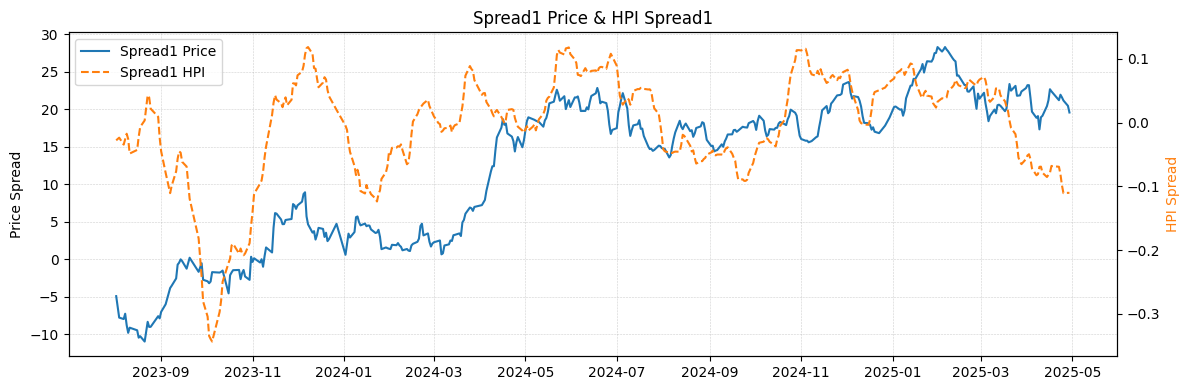

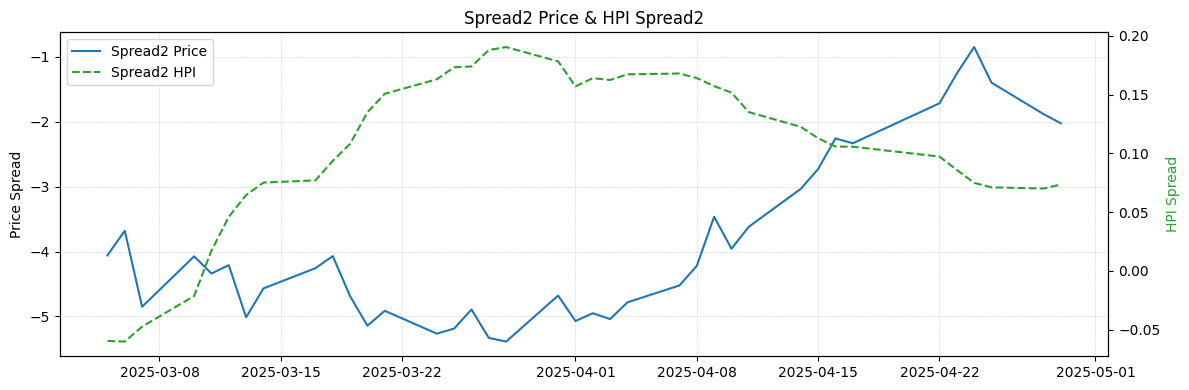

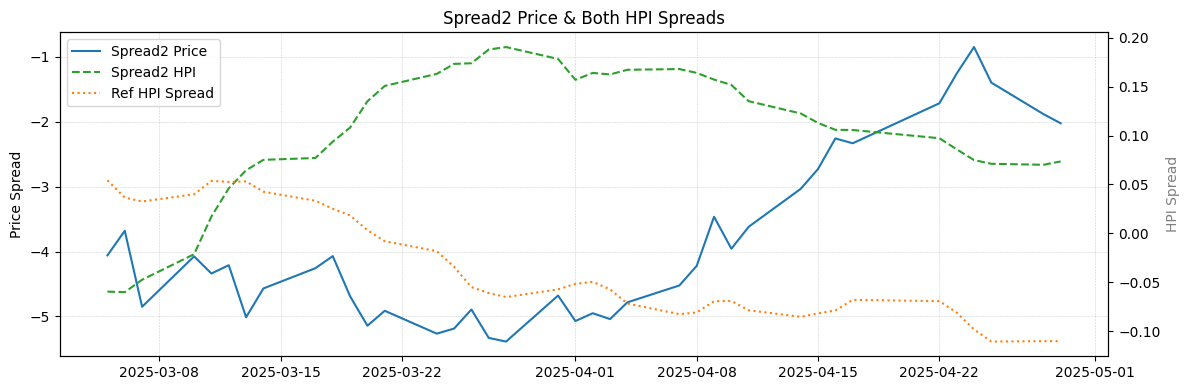

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import refinitiv.data as rd

# ───────── CONFIGURATION ─────────
LEG2A = dict(power='DEBMM5', gas='TFMBMM5', eua='CFI2Z5')
LEG2B = dict(power='DEBMN5', gas='TFMBMN5', eua='CFI2Z5')
LEG1A = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG1B = dict(power='F7BYF6', gas='TFMBYZ6', eua='CFI2Z6')

HPI_WINDOW = 30
EMA_SPAN   = 5

# ───────── HPI helper ─────────
def hpi_weighted(df, window):
    doi   = df['oi'].diff().abs()
    ratio = (doi / df['vol']).clip(0,1).fillna(0)
    sig   = np.sign(df['price_diff']).fillna(0)
    return (ratio * sig).rolling(window).mean()

# ───────── fetch one strip ─────────
def fetch_strip(codes):
    rd.open_session()
    p = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    g = rd.get_history([codes['gas'  ]], count=500)[['SETTLE']]
    e = rd.get_history([codes['eua'  ]], count=500)[['SETTLE']]
    rd.close_session()
    p.columns = ['power','oi','vol']
    g.columns = ['gas']
    e.columns = ['eua']
    raw = pd.concat([p, g, e], axis=1).dropna()
    raw['price'] = raw['power'] - 2*raw['gas'] - 0.4*raw['eua']
    df = raw[['price','oi','vol']].copy()
    df['price_diff'] = df['price'].pct_change()
    df['hpi'] = hpi_weighted(df, HPI_WINDOW)
    df['hpi_ema'] = df['hpi'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()

# ───────── build indices for both legs ─────────
A1 = fetch_strip(LEG1A)
A2 = fetch_strip(LEG1B)
B1 = fetch_strip(LEG2A)
B2 = fetch_strip(LEG2B)

# ───────── compute spreads of price and HPI ─────────
spr1 = pd.DataFrame(index=A1.index.intersection(A2.index))
spr1['price_spread'] = A1['price'] - A2['price']
spr1['hpi_spread']   = A1['hpi_ema'] - A2['hpi_ema']
spr1.dropna(inplace=True)

spr2 = pd.DataFrame(index=B1.index.intersection(B2.index))
spr2['price_spread'] = B1['price'] - B2['price']
spr2['hpi_spread']   = B1['hpi_ema'] - B2['hpi_ema']
# inject reference HPI spread
spr2['hpi_ref_spread'] = spr1['hpi_spread'].reindex(spr2.index).ffill()
spr2.dropna(inplace=True)

# ───────── PLOTTING ─────────
# Spread 1
fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(spr1.index, spr1['price_spread'], 'tab:blue', label='Spread1 Price')
ax1.set_ylabel('Price Spread'); ax1.grid(ls='--', lw=0.4, alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(spr1.index, spr1['hpi_spread'], '--', color='tab:orange', label='Spread1 HPI')
ax2.set_ylabel('HPI Spread', color='tab:orange')
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left'); plt.title('Spread1 Price & HPI Spread1')
plt.tight_layout(); plt.show()

# Spread 2 own
fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(spr2.index, spr2['price_spread'], 'tab:blue', label='Spread2 Price')
ax1.set_ylabel('Price Spread'); ax1.grid(ls='--', lw=0.4, alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(spr2.index, spr2['hpi_spread'], '--', color='tab:green', label='Spread2 HPI')
ax2.set_ylabel('HPI Spread', color='tab:green')
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left'); plt.title('Spread2 Price & HPI Spread2')
plt.tight_layout(); plt.show()

# Spread 2 with reference
fig, ax1 = plt.subplots(figsize=(12,4))
ax1.plot(spr2.index, spr2['price_spread'], 'tab:blue', label='Spread2 Price')
ax1.set_ylabel('Price Spread'); ax1.grid(ls='--', lw=0.4, alpha=0.6)
ax2 = ax1.twinx()
ax2.plot(spr2.index, spr2['hpi_spread'], '--', color='tab:green', label='Spread2 HPI')
ax2.plot(spr2.index, spr2['hpi_ref_spread'], ':', color='tab:orange', label='Ref HPI Spread')
ax2.set_ylabel('HPI Spread', color='tab:gray')
h1,l1 = ax1.get_legend_handles_labels(); h2,l2 = ax2.get_legend_handles_labels()
ax1.legend(h1+h2, l1+l2, loc='upper left'); plt.title('Spread2 Price & Both HPI Spreads')
plt.tight_layout(); plt.show()



c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

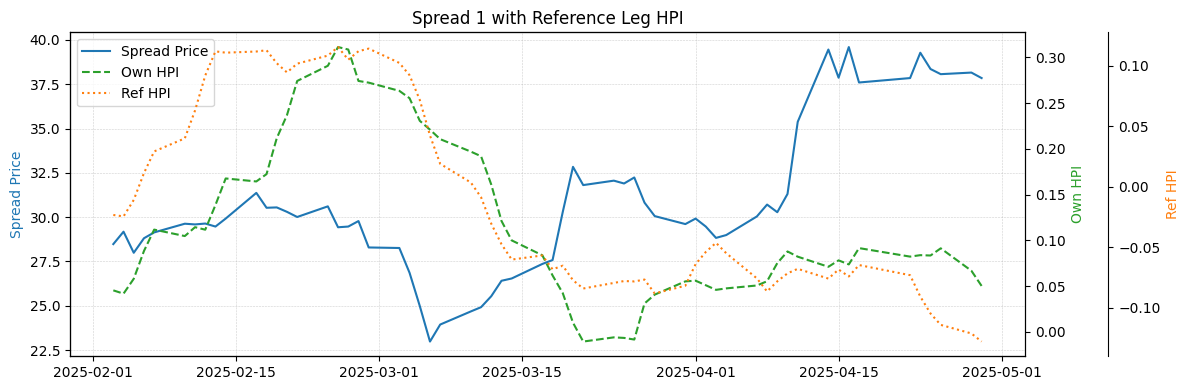

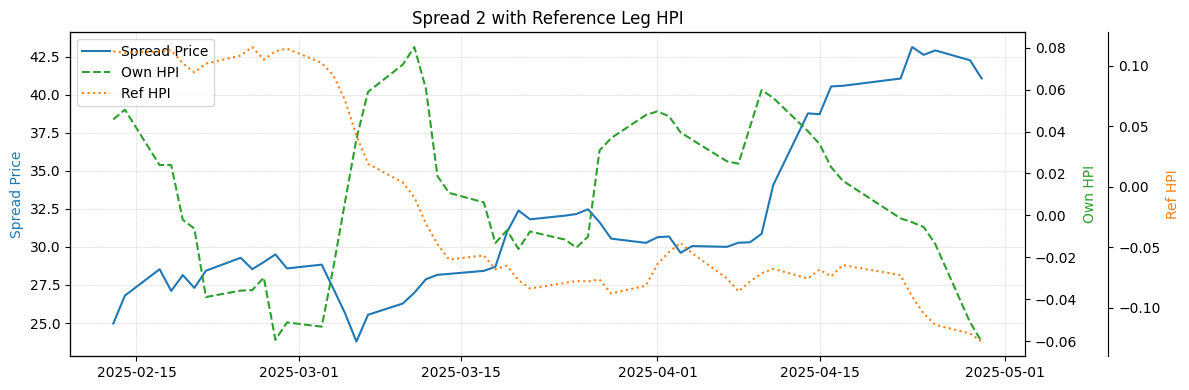

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import refinitiv.data as rd

# ───────── CONFIGURATION ─────────
# LEG1A = dict(power='DEBQN5', gas='TFMBQU5', eua='CFI2Z5')
# LEG1B = dict(power='F7BQN5', gas='TFMBQU5', eua='CFI2Z5')
# LEG1A = dict(power='DEBMM4^2', gas='TFMBMM4^2', eua='CFI2Z4^2')
# LEG1B = dict(power='F7BMM4^2', gas='TFMBMM4^2', eua='CFI2Z4^2')
# LEG2A = dict(power='DEBMN4^2', gas='TFMBMN4^2', eua='CFI2Z4^2')
# LEG2B = dict(power='F7BMN4^2', gas='TFMBMN4^2', eua='CFI2Z4^2')

LEG1A = dict(power='DEBMK5', gas='TFMBMK5', eua='CFI2Z5')
LEG1B = dict(power='F7BMK5', gas='TFMBMK5', eua='CFI2Z5')
LEG2A = dict(power='DEBMM5', gas='TFMBMM5', eua='CFI2Z5')
LEG2B = dict(power='F7BMM5', gas='TFMBMM5', eua='CFI2Z5')

# LEG1A = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
# LEG1B = dict(power='DEBYF7', gas='TFMBYZ7', eua='CFI2Z7')
# LEG2A = dict(power='FDBYF6', gas='TFMBYZ6', eua='CFI2Z6')
# LEG2B = dict(power='F9BYF6', gas='TFMBYZ6', eua='CFI2Z6')

REF   = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')  # reference leg

HPI_WINDOW = 20
EMA_SPAN   = 5

# ───────── HPI helper ─────────
def hpi_weighted(df, window):
    doi   = df['oi'].diff().abs()
    ratio = (doi / df['vol']).clip(0,1).fillna(0)
    sig   = np.sign(df['price_diff']).fillna(0)
    return (ratio * sig).rolling(window).mean()

# ───────── fetch one strip ─────────
def fetch_strip(codes):
    rd.open_session()
    p = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    g = rd.get_history([codes['gas'  ]], count=500)[['SETTLE']]
    e = rd.get_history([codes['eua'  ]], count=500)[['SETTLE']]
    rd.close_session()
    p.columns = ['power','oi','vol']; g.columns = ['gas']; e.columns = ['eua']
    raw = pd.concat([p, g, e], axis=1).dropna()
    raw['price'] = raw['power'] - 2*raw['gas'] - 0.4*raw['eua']
    df = raw[['price','oi','vol']].copy()
    df['price_diff'] = df['price'].pct_change()
    df['hpi_raw']    = hpi_weighted(df, HPI_WINDOW)
    df['hpi_ema']    = df['hpi_raw'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()

# ───────── build strips ─────────
A1 = fetch_strip(LEG1A); A2 = fetch_strip(LEG1B)
B1 = fetch_strip(LEG2A); B2 = fetch_strip(LEG2B)
R  = fetch_strip(REF)

# ───────── compute spreads ─────────
def make_spread(df1, df2):
    idx = df1.index.intersection(df2.index)
    spr = pd.DataFrame(index=idx)
    spr['price_spread'] = df1['price'].reindex(idx) - df2['price'].reindex(idx)
    spr['oi']           = df1['oi'].reindex(idx) + df2['oi'].reindex(idx)
    spr['vol']          = df1['vol'].reindex(idx) + df2['vol'].reindex(idx)
    spr['price_diff']   = spr['price_spread'].pct_change()
    spr['hpi_ema']          = df1['hpi_ema'] - df2['hpi_ema']
    # spr['hpi_ema']      = spr['hpi'].ewm(span=EMA_SPAN, adjust=False).mean()
    return spr.dropna()

# assume A1, A2, B1, B2, R are pre-loaded with columns ['price','oi','vol','price_diff','hpi_ema']

# compute spreads
spr1 = make_spread(A1, A2)
spr2 = make_spread(B1, B2)

# inject reference HPI
spr1['hpi_ref'] = R['hpi_ema'].reindex(spr1.index).ffill()
spr2['hpi_ref'] = R['hpi_ema'].reindex(spr2.index).ffill()



# ───────── PLOTTING ─────────
def plot_spread_with_ref(spr, ref, title):
    # reindex the reference HPI onto the spread’s dates
    hpi_ref = ref['hpi_ema'].reindex(spr.index).ffill()

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(spr.index, spr['price_spread'], color='tab:blue', label='Spread Price')
    ax1.set_ylabel('Spread Price', color='tab:blue')
    ax1.grid(ls='--', lw=0.4, alpha=0.6)

    # own HPI on secondary axis
    ax2 = ax1.twinx()
    ax2.plot(spr.index, spr['hpi_ema'], '--', color='tab:green', label='Own HPI')
    ax2.set_ylabel('Own HPI', color='tab:green')

    # reference HPI on tertiary axis
    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(spr.index, hpi_ref, ':', color='tab:orange', label='Ref HPI')
    ax3.set_ylabel('Ref HPI', color='tab:orange')

    # combined legend
    lines, labels = [], []
    for ax in (ax1, ax2, ax3):
        lns, lbs = ax.get_legend_handles_labels()
        lines += lns; labels += lbs
    ax1.legend(lines, labels, loc='upper left')

    plt.title(title)
    plt.tight_layout()
    plt.show()

# Then plot:
plot_spread_with_ref(spr1, R, 'Spread 1 with Reference Leg HPI')
plot_spread_with_ref(spr2, R, 'Spread 2 with Reference Leg HPI')




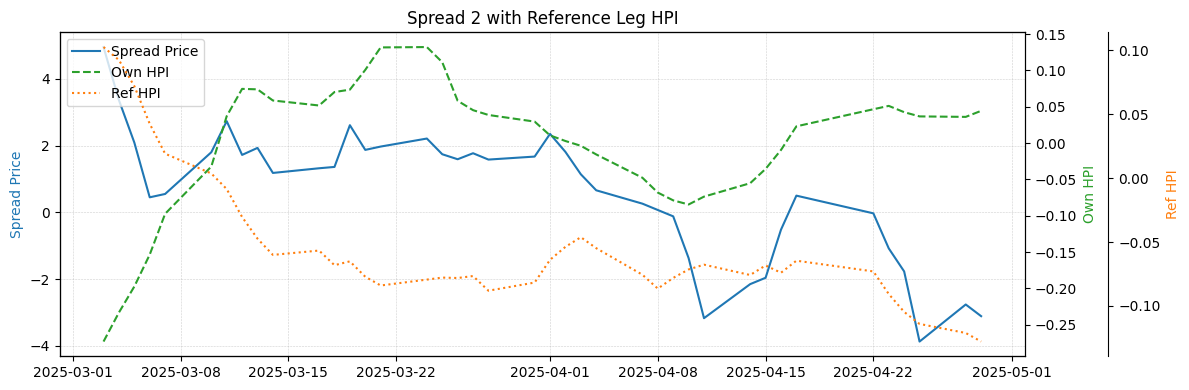

In [34]:
plot_spread_with_ref(spr2.iloc[-40:], R, 'Spread 2 with Reference Leg HPI')

c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

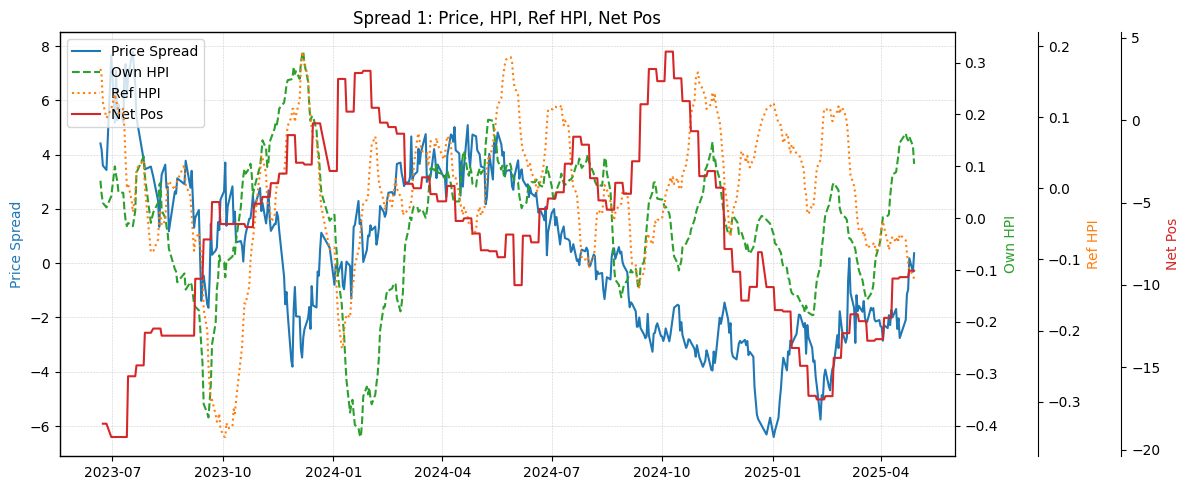

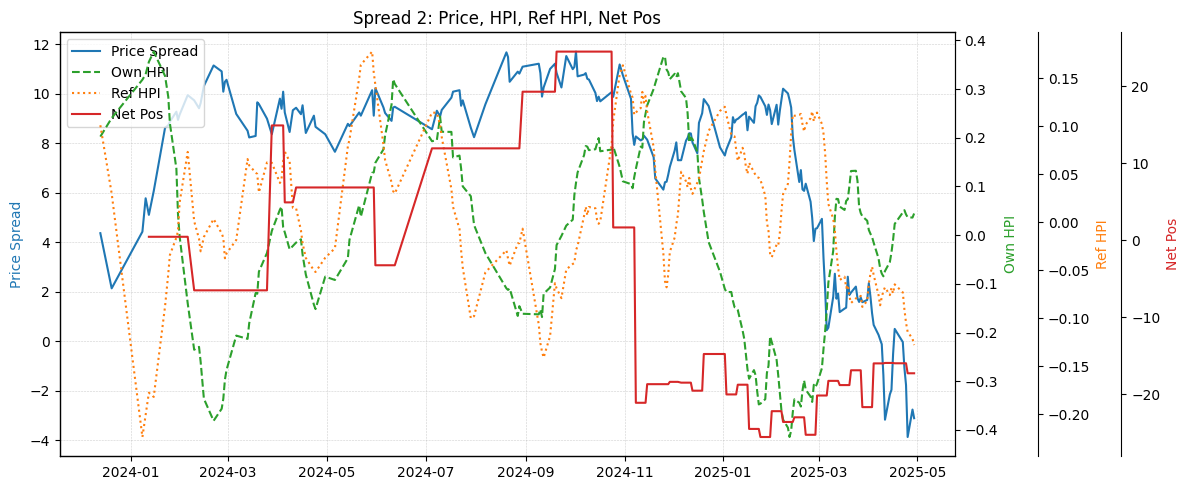

In [129]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ───────── CONFIGURATION ─────────
LEG1A = dict(power='DEBMK5', gas='TFMBMK5', eua='CFI2Z5')
LEG1B = dict(power='F7BMK5', gas='TFMBMK5', eua='CFI2Z5')
LEG2A = dict(power='DEBMM5', gas='TFMBMM5', eua='CFI2Z5')
LEG2B = dict(power='F7BMM5', gas='TFMBMM5', eua='CFI2Z5')
REF   = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')

LEG1A = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG1B = dict(power='DEBYF7', gas='TFMBYZ7', eua='CFI2Z7')
LEG2A = dict(power='FDBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG2B = dict(power='F9BYF6', gas='TFMBYZ6', eua='CFI2Z6')

HPI_WINDOW = 20
EMA_SPAN   = 5

# ───────── HPI helper ─────────
def hpi_weighted(df, window):
    doi   = df['oi'].diff().abs()
    ratio = (doi / df['vol']).clip(0,1).fillna(0)
    sig   = np.sign(df['price_diff']).fillna(0)
    return (ratio * sig).rolling(window).mean()

# ───────── fetch one strip via SQL ─────────
def fetch_strip(codes):
    rd.open_session()
    p = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    g = rd.get_history([codes['gas'  ]], count=500)[['SETTLE']]
    e = rd.get_history([codes['eua'  ]], count=500)[['SETTLE']]
    rd.close_session()
    p.columns = ['power','oi','vol']; g.columns = ['gas']; e.columns = ['eua']
    raw = pd.concat([p, g, e], axis=1).dropna()
    raw['price'] = raw['power'] - 2*raw['gas'] - 0.4*raw['eua']
    df = raw[['price','oi','vol']].copy()
    df['price_diff'] = df['price'].pct_change()
    df['hpi_raw']    = hpi_weighted(df, HPI_WINDOW)
    df['hpi_ema']    = df['hpi_raw'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()

# ───────── fetch net COT position ─────────
def fetch_net_position_sql(power_code, db):
    """
    Fetch net position = long - short for the given power_code.
    """
    dfs = get_net_pct_dfs([power_code], db)
    pos = dfs[power_code].sort_index()
    pos['net_pos'] = pos['Commer_RR']
    return pos['net_pos']

# ───────── build and plot ─────────
def make_spread(df1, df2):
    idx = df1.index.intersection(df2.index)
    spr = pd.DataFrame(index=idx)
    spr['price_spread'] = df1['price'].reindex(idx) - df2['price'].reindex(idx)
    spr['price_diff']   = spr['price_spread'].pct_change()
    spr['hpi_ema']      = df1['hpi_ema'].reindex(idx) - df2['hpi_ema'].reindex(idx)
    return spr.dropna()

def plot_spread_full(spr, ref_hpi, net_pos, title):
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(spr.index, spr['price_spread'], color='tab:blue', label='Price Spread')
    ax1.set_ylabel('Price Spread', color='tab:blue')
    ax1.grid(ls='--', lw=0.4, alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(spr.index, spr['hpi_ema'], '--', color='tab:green', label='Own HPI')
    ax2.set_ylabel('Own HPI', color='tab:green')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(spr.index, ref_hpi.reindex(spr.index), ':',
             color='tab:orange', label='Ref HPI')
    ax3.set_ylabel('Ref HPI', color='tab:orange')

    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 120))
    ax4.plot(spr.index, net_pos.reindex(spr.index).ffill(), '-',
             color='tab:red', label='Net Pos')
    ax4.set_ylabel('Net Pos', color='tab:red')

    # combined legend
    lines, labels = [], []
    for ax in (ax1, ax2, ax3, ax4):
        ln, lb = ax.get_legend_handles_labels()
        lines += ln; labels += lb
    ax1.legend(lines, labels, loc='upper left')

    plt.title(title)
    plt.tight_layout()
    plt.show()

# 1) Fetch strips
A1 = fetch_strip(LEG1A)
A2 = fetch_strip(LEG1B)
B1 = fetch_strip(LEG2A)
B2 = fetch_strip(LEG2B)
R  = fetch_strip(REF)

# 2) Build spreads
spr1 = make_spread(A1, A2)
spr2 = make_spread(B1, B2)

# 3) Fetch net positions
# net1 = fetch_net_position_sql('DEBM', db) - fetch_net_position_sql('F7BM', db)
net1 = fetch_net_position_sql('DEBM', db)
net2 = fetch_net_position_sql('FDBM', db) - fetch_net_position_sql('F9BM', db)

# 4) Plot
plot_spread_full(spr1, R['hpi_ema'], net1, 'Spread 1: Price, HPI, Ref HPI, Net Pos')
plot_spread_full(spr2, R['hpi_ema'], net2, 'Spread 2: Price, HPI, Ref HPI, Net Pos')


c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
c:\Users\krajcovic\anaconda3\envs\develop_matej\Lib\site-packages\refinitiv\data\_tools\_dataframe.py:177:FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(cop

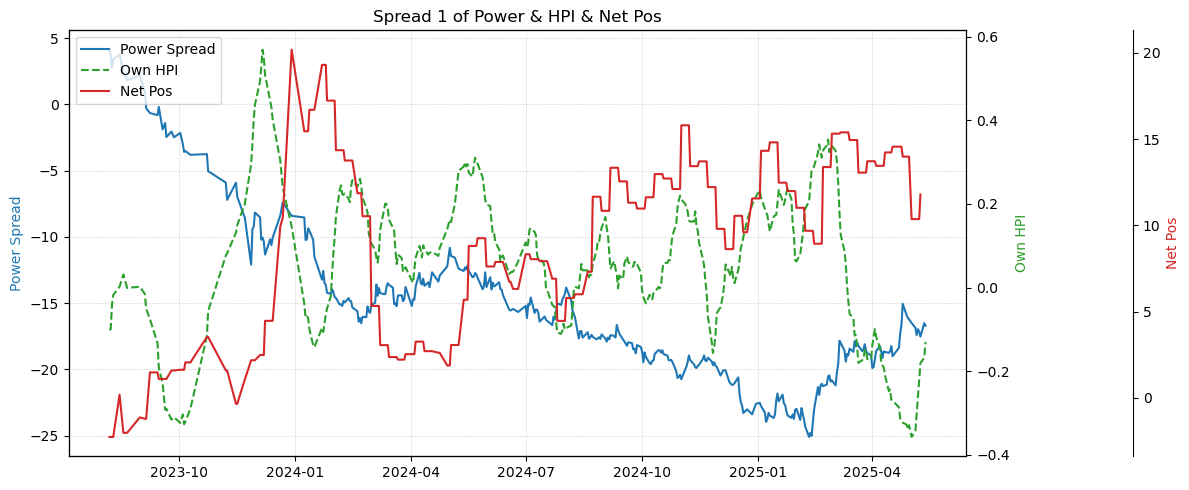

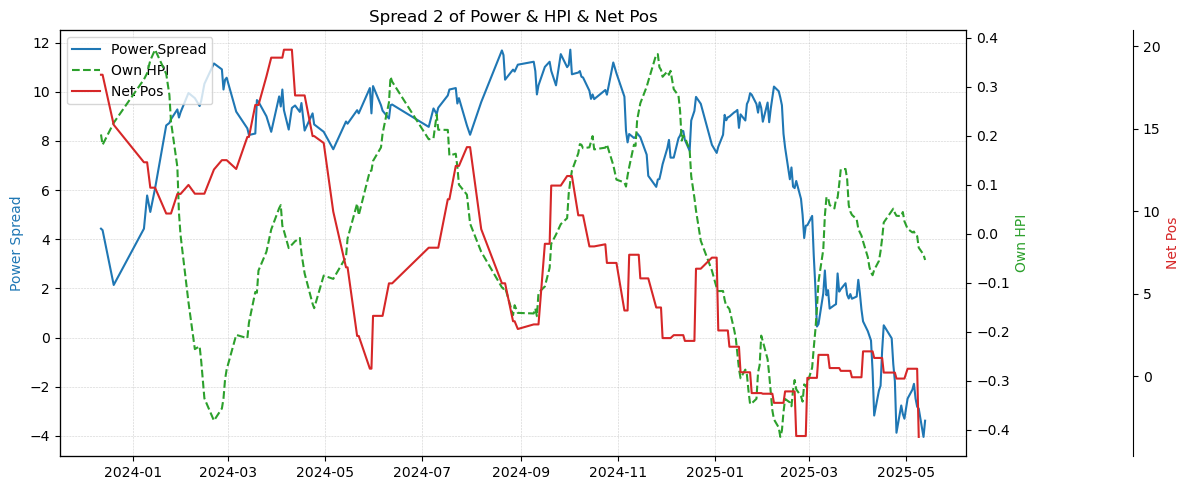

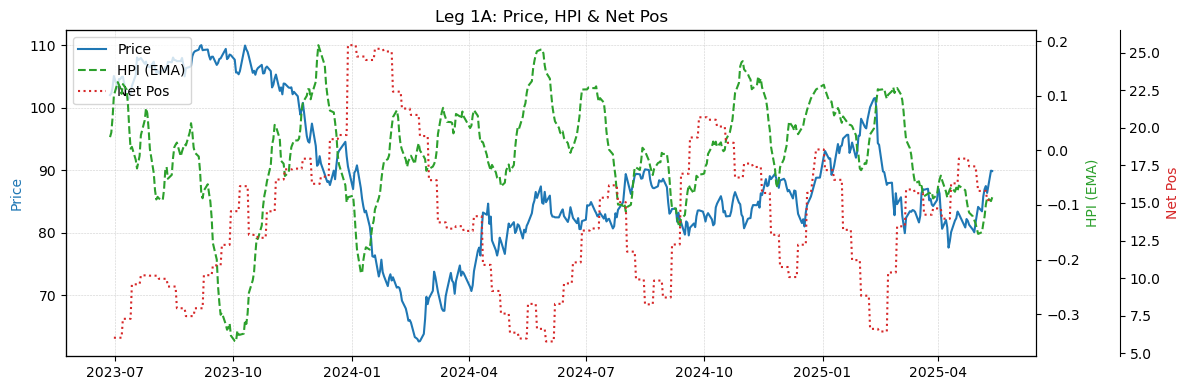

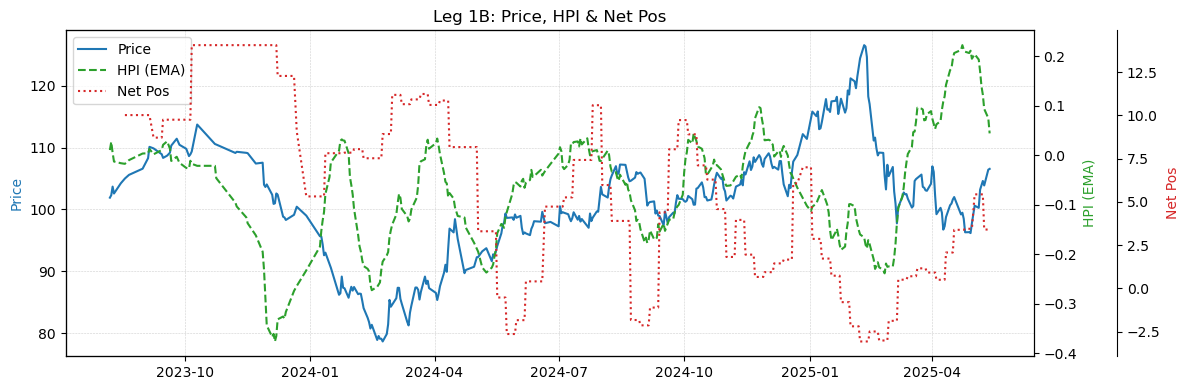

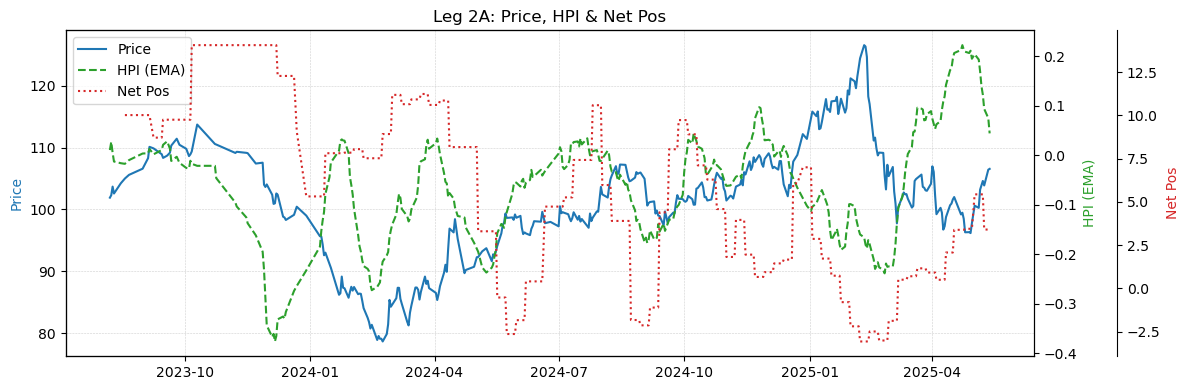

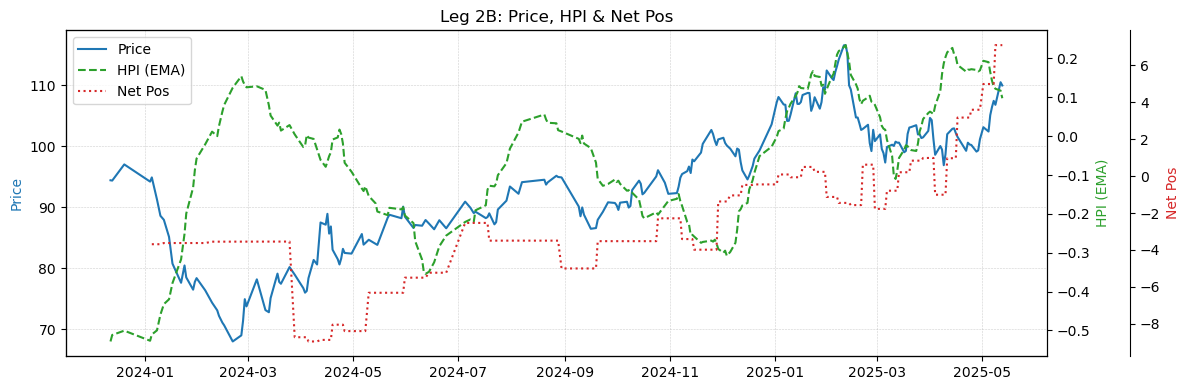

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import refinitiv.data as rd  # or your data source

# ───────── CONFIGURATION ─────────
LEG1A = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG1B = dict(power='F7BYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG2A = dict(power='DEBMM5', gas='TFMBMM5', eua='CFI2Z5')
LEG2B = dict(power='F7BMM5', gas='TFMBMM5', eua='CFI2Z5')
REF   = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')

# LEG1A = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
# LEG1B = dict(power='ATBYF6', gas='TFMBYZ6', eua='CFI2Z6')
# LEG2A = dict(power='DEBQV5', gas='TFMBQZ5', eua='CFI2Z5')
# LEG2B = dict(power='ATBQV5', gas='TFMBQZ5', eua='CFI2Z5')
# REF   = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')

LEG1A = dict(power='DEBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG1B = dict(power='FDBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG2A = dict(power='FDBYF6', gas='TFMBYZ6', eua='CFI2Z6')
LEG2B = dict(power='F9BYF6', gas='TFMBYZ6', eua='CFI2Z6')

HPI_WINDOW = 20
EMA_SPAN   = 5

# ───────── HPI helper (price-based) ─────────
def hpi_weighted(df, window):
    doi   = df['oi'].diff().abs()
    ratio = (doi / df['vol']).clip(0,1).fillna(0)
    sig   = np.sign(df['price_diff']).fillna(0)
    return (sig * ratio).rolling(window).mean()

# ───────── fetch one strip ─────────
def fetch_strip(codes):
    rd.open_session()
    p = rd.get_history([codes['power']], count=500)[['SETTLE','OPINT_1','ACVOL_UNS']]
    g = rd.get_history([codes['gas']], count=500)[['SETTLE']]
    e = rd.get_history([codes['eua'  ]], count=500)[['SETTLE']]
    rd.close_session()
    p.columns = ['power','oi','vol']; g.columns = ['gas']; e.columns = ['eua']
    raw = pd.concat([p, g, e], axis=1).dropna()
    raw['price'] = raw['power'] - 2*raw['gas'] - 0.4*raw['eua']
    # raw['price'] = raw['power']
    df = raw[['price','oi','vol', 'power']].copy()
    df['price_diff'] = df['price'].pct_change()
    df['hpi_raw']    = hpi_weighted(df, HPI_WINDOW)
    df['hpi_ema']    = df['hpi_raw'].ewm(span=EMA_SPAN, adjust=False).mean()
    return df.dropna()
# ───────── build spreads ─────────
def make_spread(df1, df2):
    idx = df1.index.intersection(df2.index)
    spr = pd.DataFrame(index=idx)
    # NEW: power spread on primary axis
    spr['power_spread'] = df1['power'].reindex(idx) - df2['power'].reindex(idx)
    # price‐HPI difference
    spr['hpi_ema']      = df1['hpi_ema'].reindex(idx) - df2['hpi_ema'].reindex(idx)
    return spr.dropna()

# ───────── fetch net COT position ─────────
def fetch_net_position_sql(power_code, db):
    """
    Fetch net position = long - short for the given power_code.
    """
    dfs = get_net_pct_dfs([power_code], db)
    pos = dfs[power_code].sort_index()
    pos['net_pos'] = pos[[a for a in pos.columns if 'NRR' not in a]].sum(axis=1)
    pos['net_pos'] = pos[[a for a in pos.columns if 'Commer' in a]].sum(axis=1)
    return pos['net_pos']

# ───────── plot helper ─────────
def plot_power_spread(spr, ref_hpi, net_pos, title):
    fig, ax1 = plt.subplots(figsize=(12,5))
    ax1.plot(spr.index, spr['power_spread'], color='tab:blue', label='Power Spread')
    ax1.set_ylabel('Power Spread', color='tab:blue')
    ax1.grid(ls='--', lw=0.4, alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(spr.index, spr['hpi_ema'], '--', color='tab:green', label='Own HPI')
    ax2.set_ylabel('Own HPI', color='tab:green')

    # ax3 = ax1.twinx()
    # ax3.spines['right'].set_position(('outward', 60))
    # ax3.plot(spr.index, ref_hpi.reindex(spr.index), ':',
    #          color='tab:orange', label='Ref HPI')
    # ax3.set_ylabel('Ref HPI', color='tab:orange')

    ax4 = ax1.twinx()
    ax4.spines['right'].set_position(('outward', 120))
    ax4.plot(spr.index, net_pos.resample('D').ffill().reindex(spr.index).bfill(), '-',
             color='tab:red', label='Net Pos')
    ax4.set_ylabel('Net Pos', color='tab:red')

    # combined legend
    lines, labels = [], []
    for ax in (ax1, ax2, ax4):
        ln, lb = ax.get_legend_handles_labels()
        lines += ln; labels += lb
    ax1.legend(lines, labels, loc='upper left')

    plt.title(title)
    plt.tight_layout()
    plt.show()

# ───────── main ─────────
A1 = fetch_strip(LEG1A); A2 = fetch_strip(LEG1B)
B1 = fetch_strip(LEG2A); B2 = fetch_strip(LEG2B)
R  = fetch_strip(REF)

spr1 = make_spread(A1, A2)
spr2 = make_spread(B1, B2)

net1 = fetch_net_position_sql('DEBM', db) - fetch_net_position_sql('FDBM', db)
net2 = fetch_net_position_sql('FDBM', db) - fetch_net_position_sql('F9BM', db)

plot_power_spread(spr1, R['hpi_ema'], net1, 'Spread 1 of Power & HPI & Net Pos')
plot_power_spread(spr2, R['hpi_ema'], net2, 'Spread 2 of Power & HPI & Net Pos')

# ───────── plot individual legs with their net position ─────────
def plot_leg_with_net(df, power_code, title):
    # fetch leg net position
    net_pos = fetch_net_position_sql(power_code, db).reindex(df.index).ffill()
    
    fig, ax1 = plt.subplots(figsize=(12,4))
    ax1.plot(df.index, df['power'],  color='tab:blue',  label='Price')
    ax1.set_ylabel('Price', color='tab:blue')
    ax1.grid(ls='--', lw=0.4, alpha=0.6)

    ax2 = ax1.twinx()
    ax2.plot(df.index, df['hpi_ema'], '--', color='tab:green', label='HPI (EMA)')
    ax2.set_ylabel('HPI (EMA)', color='tab:green')

    ax3 = ax1.twinx()
    ax3.spines['right'].set_position(('outward', 60))
    ax3.plot(df.index, net_pos, ':', color='tab:red', label='Net Pos')
    ax3.set_ylabel('Net Pos', color='tab:red')

    # combined legend
    lines, labels = [], []
    for ax in (ax1, ax2, ax3):
        ln, lb = ax.get_legend_handles_labels()
        lines += ln; labels += lb
    ax1.legend(lines, labels, loc='upper left')

    plt.title(title)
    plt.tight_layout()
    plt.show()

# Now call for each leg:
plot_leg_with_net(A1, 'DEBM', 'Leg 1A: Price, HPI & Net Pos')
plot_leg_with_net(A2, 'FDBM', 'Leg 1B: Price, HPI & Net Pos')
plot_leg_with_net(B1, 'FDBM', 'Leg 2A: Price, HPI & Net Pos')
plot_leg_with_net(B2, 'F9BM', 'Leg 2B: Price, HPI & Net Pos')




In [6]:
test = get_net_pct_dfs(['F9BM'], db)['F9BM']


In [7]:
test.columns

Index(['Commer_NRR', 'Commer_RR', 'CreditInst_NRR', 'CreditInst_RR',
       'InvFunds_NRR', 'InvFunds_RR', 'Operators_NRR', 'Operators_RR',
       'OtherIns_NRR', 'OtherIns_RR'],
      dtype='object')

<Axes: xlabel='date'>

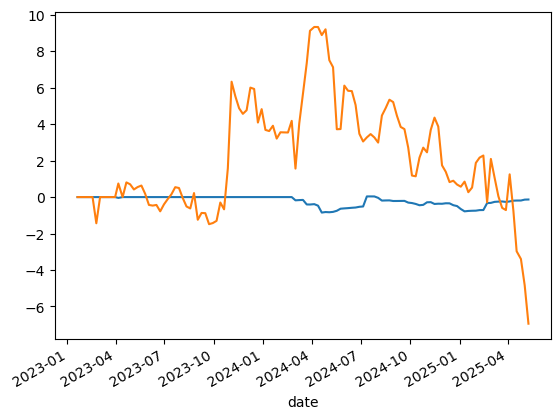

In [18]:
test[[a for a in test.columns if ('NRR' not in a) and ('Commer' not in a)]].sum(axis=1).plot()
test[[a for a in test.columns if ('NRR' in a) and ('Commer' not in a)]].sum(axis=1).plot()

In [19]:
test[[a for a in test.columns if ('NRR' not in a) and ('Commer' not in a)]]

,CreditInst_RR,InvFunds_RR,Operators_RR,OtherIns_RR
date,,,,
2023-01-20,0.000000,0.0,0.0,0.0
2023-01-27,0.000000,0.0,0.0,0.0
2023-02-03,0.000000,0.0,0.0,0.0
2023-02-10,0.000000,0.0,0.0,0.0
2023-02-17,0.000000,0.0,0.0,0.0
...,...,...,...,...
2025-04-11,-0.197019,0.0,0.0,0.0
2025-04-17,-0.190072,0.0,0.0,0.0
2025-04-25,-0.188401,0.0,0.0,0.0


<Axes: xlabel='date'>

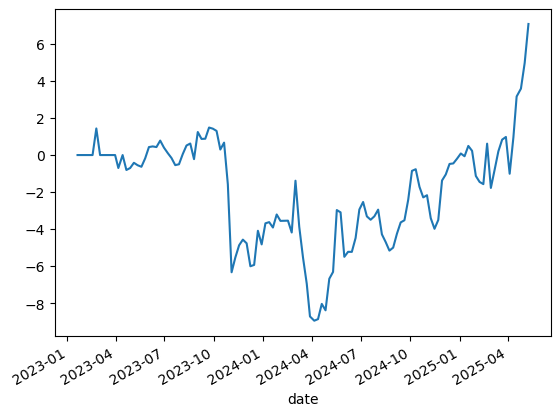

In [10]:
test[[a for a in test.columns if 'Commer' in a]].sum(axis=1).plot()

<Axes: xlabel='date'>

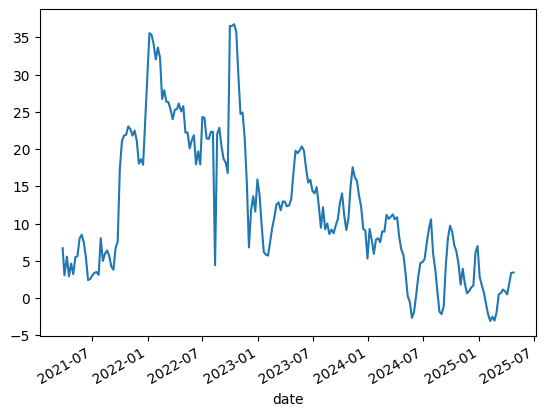

In [141]:

fetch_net_position_sql('FDBM', db).plot()